# Revisión de Airbnb — copia corregida

Copia de `revisar_airbnb.ipynb` con cuatro correcciones. **El original se conserva sin tocar.**

| Celda | Qué fallaba | Efecto medido |
|---|---|---|
| 2 | Clasificaba buscando `HUTB` en la cadena entera, y el campo contiene el número regional **y** el nacional, que lo embebe | 37 anuncios mal clasificados: 29 con exención declarada y 8 hoteleros contados como VUT |
| 2 | La regla `"NT" in texto` capturaba el «nt» de `Exempt - tourist apartme**nt**` | 45 anuncios metidos en alquiler de temporada sin serlo |
| 14, 18 | Filtraban por distancia `< 150 m` entre anuncios | El umbral cae **dentro del ruido**: la fuente desplaza cada anuncio hasta 150 m de forma independiente, y dos pisos del mismo portal superan ese umbral el **41%** de las veces |
| 22 | Imputaba `minimum_nights = 31` sin justificarlo | 31 no es neutro: es el máximo que sigue siendo uso turístico |

**La corrección de fondo es la del umbral de distancia.** No es que 150 m sea poco o mucho: es que
las coordenadas de Inside Airbnb llevan un desplazamiento aleatorio de ese mismo orden, aplicado
anuncio a anuncio. Cualquier criterio en la franja de 100 a 300 metros mide sobre todo el ruido.
Donde hacía falta «misma vivienda» ahora manda la licencia, que es exacta; donde hacía falta
«misma zona», el barrio, que ya viene en el fichero.

In [1]:
# 1. Carga
#
# CORREGIDO: leia el volcado resumido de Inside Airbnb, de 19 columnas, que no trae `accommodates`.
# Sin capacidad no se puede calcular precio por plaza, que es la unica escala en la que un piso
# entero y una habitacion de hotel se comparan.
#
# Ahora lee `data/bronze/airbnb_anuncios.csv`, que `pipeline/bronze/unificar_airbnb.py` construye
# uniendo ese volcado con el de detalle --90 columnas-- y que ya trae capacidad, precio limpio y
# precio por plaza. Ese fichero es tambien la unica cadena de Airbnb del proyecto: antes habia dos
# corriendo en paralelo y la web publicaba desde la que no mandaba.

from pathlib import Path

import pandas as pd

RAIZ = Path.cwd()
while not (RAIZ / "data").exists() and RAIZ != RAIZ.parent:
    RAIZ = RAIZ.parent

df = pd.read_csv(RAIZ / "data" / "bronze" / "airbnb_anuncios.csv", low_memory=False)

# El resto del cuaderno se escribio contra la columna `price` del volcado crudo. `precio_anuncio`
# es la misma magnitud ya limpia de simbolos, asi que se expone con los dos nombres en vez de
# reescribir doce celdas.
df["price"] = df["precio_anuncio"]
total_registros = len(df)

print("=== 1. CARGA ===")
print(f"Anuncios: {total_registros:,}  |  columnas: {len(df.columns)}")
print(f"  con capacidad declarada  : {int(df['accommodates'].notna().sum()):,}")
print(f"  con precio               : {int(df['precio_anuncio'].notna().sum()):,}")
print(f"  con precio por plaza     : {int(df['precio_por_plaza'].notna().sum()):,}")

=== 1. CARGA ===
Anuncios: 15,406  |  columnas: 24
  con capacidad declarada  : 15,293
  con precio               : 13,465
  con precio por plaza     : 13,355


In [2]:
# 2. Clasificación de licencias según tipo de registro
#
# CORREGIDO (dos fallos):
#
# 1) Buscaba "HUTB" en la cadena entera, y el campo `license` contiene DOS números: el regional
#    y el nacional, que embebe al regional. Un anuncio cuyo campo regional dice "Exempt" pero
#    cuyo número nacional contiene HUTB salía clasificado como apartamento turístico. Eran 37
#    anuncios: 29 con exención declarada y 8 con licencia hotelera.
#    Ahora se extrae primero la sección regional, que es la que manda, y se clasifica sobre ella.
#
# 2) La regla `("NT" in lic_upper and has_digits)` capturaba 45 anuncios que no son alquiler de
#    temporada: el "NT" venía de "Exempt - tourist apartme(nt)". Un hotel y un apartament turístic
#    acababan en la categoría de temporada. Se deja solo el código explícito ESFCNT/ESHFNT.

import re

PATRON_REGIONAL = re.compile(
    r"Barcelona\s*-\s*Regional registration number\s*(?:<br\s*/?>)*\s*([^<]*)", re.I)


def seccion_regional(texto):
    """El número que Barcelona exige declarar, aislado del nacional que lo contiene."""
    if pd.isna(texto):
        return None
    m = PATRON_REGIONAL.search(str(texto))
    return m.group(1).strip() if m else None


def clasificar_licencia(row):
    """Clasifica el anuncio por su licencia REGIONAL, no por el texto completo del campo.

    - HUTB / HUT      -> vivienda de uso turístico, lo que la ley de 2028 elimina
    - HB / HCC        -> licencia hotelera
    - AJ              -> albergue
    - ATB / ATCC      -> apartament turístic (otra figura legal, no es HUT)
    - ESFCNT / ESHFNT -> alquiler de temporada declarado en el registro nacional
    - Exempt, vacío   -> sin licencia declarada
    """
    regional = seccion_regional(row["license"])
    nacional = str(row["license"]) if pd.notna(row["license"]) else ""

    if regional:
        r = regional.upper()
        if r.startswith("HUTB") or r.startswith("HUT"):
            return "Apartamento turístico (HUTB / TU)"
        if r.startswith("HB") or r.startswith("HCC"):
            return "Licencia hotelera (HB)"
        if r.startswith("AJ"):
            return "Licencia albergue (AJ)"
        if r.startswith("ATB") or r.startswith("ATCC"):
            return "Apartament turístic (ATB)"
        if "EXEMPT" in r:
            return "Exención declarada"

    # Sin sección regional utilizable, se recurre al número nacional: la NRUA embebe la licencia
    # autonómica, así que sigue siendo información válida, solo que de segunda mano.
    n = nacional.upper()
    if "ESFCTU" in n or "ESHFTU" in n:
        return "Apartamento turístico (HUTB / TU)"
    if "ESFCNT" in n or "ESHFNT" in n:
        return "No turístico (Alquiler de temporada / NT)"
    return "Sin licencia / Nula"


df["licencia_regional"] = df["license"].map(seccion_regional)
df["categoria_licencia"] = df.apply(clasificar_licencia, axis=1)

resumen = df["categoria_licencia"].value_counts().reset_index()
resumen.columns = ["Categoría de Licencia", "Total Registros"]
resumen["Porcentaje (%)"] = (resumen["Total Registros"] / total_registros * 100).round(2)

print("--- DESGLOSE TOTAL DE LICENCIAS Y PORCENTAJE (%) ---")
display(resumen)

# Comprobación de que la corrección hace lo que dice
mal_antes = df[(df["categoria_licencia"] != "Apartamento turístico (HUTB / TU)")
               & df["license"].astype(str).str.upper().str.contains("HUTB", na=False)]
print(f"\nAnuncios con 'HUTB' en el texto que NO son vivienda de uso turístico: {len(mal_antes):,}")
print("La versión anterior los contaba a todos como apartamento turístico.")

--- DESGLOSE TOTAL DE LICENCIAS Y PORCENTAJE (%) ---


,Categoría de Licencia,Total Registros,Porcentaje (%)
0,Apartamento turístico (HUTB / TU),7428,48.21
1,Sin licencia / Nula,3189,20.70
2,Exención declarada,2960,19.21
3,No turístico (Alquiler de temporada / NT),928,6.02
4,Licencia hotelera (HB),670,4.35
5,Licencia albergue (AJ),203,1.32
6,Apartament turístic (ATB),28,0.18



Anuncios con 'HUTB' en el texto que NO son vivienda de uso turístico: 28
La versión anterior los contaba a todos como apartamento turístico.


In [3]:
# 3. Análisis cruzado por categoría de licencia y tipo de habitación (room_type)

def analizar_licencias_por_tipo_habitacion(df_datos):
    """
    Analiza el desglose de categorías de licencia cruzado exclusivamente con el tipo
    de habitación ('room_type') y muestra los textos de licencia más habituales.
    
    Args:
        df_datos (pd.DataFrame): DataFrame con la columna 'categoria_licencia' y 'room_type'.
        
    Returns:
        pd.DataFrame: Tabla cruzada de categorías de licencia por room_type.
    """
    print("--- 1. Valores más frecuentes en la columna 'license' ---")
    display(df_datos["license"].value_counts(dropna=False).head(15).reset_index())
    
    print("\n--- 2. Desglose por categoría de licencia y tipo de habitación ('room_type') ---")
    desglose = pd.crosstab(
        df_datos["categoria_licencia"], 
        df_datos["room_type"], 
        margins=True, 
        margins_name="Total"
    ).sort_values(by="Total", ascending=False)
    
    display(desglose)
    
    return desglose

# Ejecutar análisis cruzado
tabla_desglose = analizar_licencias_por_tipo_habitacion(df)


--- 1. Valores más frecuentes en la columna 'license' ---


,license,count
0,NaN,3156
1,Barcelona - Regional registration number<br />...,194
2,Spain - National registration number<br />Exem...,118
3,Spain - National registration number<br />ESFC...,41
4,Barcelona - Regional registration number<br />...,25
5,Barcelona - Regional registration number<br />...,24
6,Barcelona - Regional registration number<br />...,22
7,Barcelona - Regional registration number<br />...,20
8,Spain - National registration number<br />ESFC...,20
9,Barcelona - Regional registration number<br />...,17



--- 2. Desglose por categoría de licencia y tipo de habitación ('room_type') ---


room_type,Entire home/apt,Hotel room,Private room,Shared room,Total
categoria_licencia,,,,,
Total,10844,68,4375,119,15406
Apartamento turístico (HUTB / TU),6768,14,644,2,7428
Sin licencia / Nula,1165,0,2014,10,3189
Exención declarada,2145,0,814,1,2960
No turístico (Alquiler de temporada / NT),692,0,229,7,928
Licencia hotelera (HB),53,49,560,8,670
Licencia albergue (AJ),0,5,107,91,203
Apartament turístic (ATB),21,0,7,0,28


In [4]:
# 4. Filtrado de apartamentos turísticos y sin licencia sin comentarios en los últimos 12 meses

def analizar_inactivos_12m(df_datos):
    """
    Filtra las categorías 'Apartamento turístico (HUTB / TU)' y 'Sin licencia / Nula',
    excluyendo los registros que tengan comentarios en los últimos 12 meses
    (number_of_reviews_ltm > 0).
    
    Calcula los totales y porcentajes combinados ('de ambos') y por separado.
    
    Args:
        df_datos (pd.DataFrame): DataFrame original con 'categoria_licencia' y 'number_of_reviews_ltm'.
        
    Returns:
        pd.DataFrame: DataFrame filtrado con los registros sin comentarios en 12m.
    """
    # Categorías de interés
    categorias_interes = ["Apartamento turístico (HUTB / TU)", "Sin licencia / Nula"]
    
    # Filtrar solo esas 2 categorías
    df_interes = df_datos[df_datos["categoria_licencia"].isin(categorias_interes)].copy()
    
    # Quitar registros con comentarios en los últimos 12 meses (conservar number_of_reviews_ltm == 0)
    df_sin_resenas = df_interes[df_interes["number_of_reviews_ltm"] == 0].copy()
    
    total_general = len(df_datos)
    total_interes = len(df_interes)
    total_sin_resenas_ambos = len(df_sin_resenas)
    
    print("--- 1. RESUMEN COMBINADO (AMBOS GRUPOS SIN RESEÑAS EN 12 MESES) ---")
    print(f"Total combinado sin comentarios en 12m: {total_sin_resenas_ambos:,}")
    print(f"Porcentaje sobre las 2 categorías ({total_interes:,}): {(total_sin_resenas_ambos / total_interes * 100):.2f}%")
    print(f"Porcentaje sobre el total del dataset ({total_general:,}): {(total_sin_resenas_ambos / total_general * 100):.2f}%\n")
    
    # Desglose por separado
    registros_separado = []
    for cat in categorias_interes:
        tot_cat_original = len(df_datos[df_datos["categoria_licencia"] == cat])
        tot_cat_sin_resenas = len(df_sin_resenas[df_sin_resenas["categoria_licencia"] == cat])
        pct_sobre_categoria = (tot_cat_sin_resenas / tot_cat_original * 100) if tot_cat_original > 0 else 0
        pct_sobre_dataset = (tot_cat_sin_resenas / total_general * 100)
        
        registros_separado.append({
            "Categoría": cat,
            "Sin comentarios (12m)": tot_cat_sin_resenas,
            "Total categoría": tot_cat_original,
            "% sobre su categoría": round(pct_sobre_categoria, 2),
            "% sobre total dataset": round(pct_sobre_dataset, 2)
        })
        
    tabla_separado = pd.DataFrame(registros_separado)
    print("--- 2. DESGLOSE POR SEPARADO ---")
    display(tabla_separado)
    
    return df_sin_resenas

# Ejecutar análisis de inactivos en los últimos 12 meses
df_inactivos_12m = analizar_inactivos_12m(df)


--- 1. RESUMEN COMBINADO (AMBOS GRUPOS SIN RESEÑAS EN 12 MESES) ---
Total combinado sin comentarios en 12m: 3,496
Porcentaje sobre las 2 categorías (10,617): 32.93%
Porcentaje sobre el total del dataset (15,406): 22.69%

--- 2. DESGLOSE POR SEPARADO ---


,Categoría,Sin comentarios (12m),Total categoría,% sobre su categoría,% sobre total dataset
0,Apartamento turístico (HUTB / TU),1221,7428,16.44,7.93
1,Sin licencia / Nula,2275,3189,71.34,14.77


In [5]:
# 5. Detección de duplicados literales en alojamientos activos (con comentarios en los últimos 12 meses)

def analizar_duplicados_activos_12m(df_datos):
    """
    Filtra los alojamientos de las categorías 'Apartamento turístico (HUTB / TU)' y
    'Sin licencia / Nula' que hayan estado activos en los últimos 12 meses (number_of_reviews_ltm > 0).
    
    Identifica duplicados literales bajo diferentes criterios (identidad exacta, mismo nombre/anfitrión,
    y misma licencia), mostrando los totales y porcentajes agrupados (juntos) y por separado.
    
    Args:
        df_datos (pd.DataFrame): DataFrame original con las categorías de licencia y número de reseñas.
        
    Returns:
        pd.DataFrame: DataFrame filtrado con el universo activo analizado.
    """
    categorias_interes = ["Apartamento turístico (HUTB / TU)", "Sin licencia / Nula"]
    
    # 1. Filtrar universo activo (con reseñas en los últimos 12 meses)
    mask_activos = df_datos["categoria_licencia"].isin(categorias_interes) & (df_datos["number_of_reviews_ltm"] > 0)
    df_activos = df_datos[mask_activos].copy()
    
    tot_general_activos = len(df_activos)
    tot_apt_activos = len(df_activos[df_activos["categoria_licencia"] == "Apartamento turístico (HUTB / TU)"])
    tot_sin_activos = len(df_activos[df_activos["categoria_licencia"] == "Sin licencia / Nula"])
    
    print("--- 1. UNIVERSO ACTIVO (CON COMENTARIOS EN ÚLTIMOS 12 MESES) ---")
    print(f"Total activo combinado (ambas categorías): {tot_general_activos:,}")
    print(f"  - Apartamentos turísticos (HUTB / TU): {tot_apt_activos:,}")
    print(f"  - Sin licencia / Nula: {tot_sin_activos:,}\n")
    
    # 2. Criterios de duplicación
    criterios = {
        "Duplicados exactos por identidad (nombre, anfitrión, coords, tipo, precio)": ["name", "host_id", "latitude", "longitude", "room_type", "price"],
        "Duplicados por mismo nombre y anfitrión (name, host_id)": ["name", "host_id"],
        "Duplicados por misma licencia (código repetido)": ["license"]
    }
    
    resultados_duplicados = []
    
    for nombre_criterio, columnas_criterio in criterios.items():
        if columnas_criterio == ["license"]:
            mask_dup = df_activos["license"].notna() & df_activos.duplicated(subset=columnas_criterio, keep=False)
        else:
            mask_dup = df_activos.duplicated(subset=columnas_criterio, keep=False)
            
        df_dup = df_activos[mask_dup]
        
        n_juntos = len(df_dup)
        pct_juntos = (n_juntos / tot_general_activos * 100) if tot_general_activos > 0 else 0
        
        n_apt = len(df_dup[df_dup["categoria_licencia"] == "Apartamento turístico (HUTB / TU)"])
        pct_apt = (n_apt / tot_apt_activos * 100) if tot_apt_activos > 0 else 0
        
        n_sin = len(df_dup[df_dup["categoria_licencia"] == "Sin licencia / Nula"])
        pct_sin = (n_sin / tot_sin_activos * 100) if tot_sin_activos > 0 else 0
        
        resultados_duplicados.append({
            "Criterio de Duplicación": nombre_criterio,
            "Total Juntos": n_juntos,
            "% Juntos": round(pct_juntos, 2),
            "Apt. Turístico": n_apt,
            "% Apt. Turístico": round(pct_apt, 2),
            "Sin Licencia": n_sin,
            "% Sin Licencia": round(pct_sin, 2)
        })
        
    tabla_duplicados = pd.DataFrame(resultados_duplicados)
    
    print("--- 2. ANÁLISIS DE DUPLICADOS LITERALES (TOTALES Y % JUNTOS Y POR SEPARADO) ---")
    display(tabla_duplicados)
    
    return df_activos

# Ejecutar análisis de duplicados en el universo activo
df_universo_activo = analizar_duplicados_activos_12m(df)


--- 1. UNIVERSO ACTIVO (CON COMENTARIOS EN ÚLTIMOS 12 MESES) ---
Total activo combinado (ambas categorías): 7,121
  - Apartamentos turísticos (HUTB / TU): 6,207
  - Sin licencia / Nula: 914

--- 2. ANÁLISIS DE DUPLICADOS LITERALES (TOTALES Y % JUNTOS Y POR SEPARADO) ---


,Criterio de Duplicación,Total Juntos,% Juntos,Apt. Turístico,% Apt. Turístico,Sin Licencia,% Sin Licencia
0,"Duplicados exactos por identidad (nombre, anfi...",33,0.46,29,0.47,4,0.44
1,"Duplicados por mismo nombre y anfitrión (name,...",230,3.23,186,3.00,44,4.81
2,Duplicados por misma licencia (código repetido),295,4.14,277,4.46,18,1.97


In [6]:
# 6. Desglose de duplicados por combinaciones clave (Nombre+Anfitrión, Licencia, Anfitrión+Licencia, y Anfitrión+Licencia+Precio)

def desglosar_duplicados_por_tipo(df_datos):
    """
    Analiza los alojamientos duplicados según diversas combinaciones de campos:
    - Nombre + Anfitrión (name, host_id).
    - Misma Licencia (license).
    - Nombre + Anfitrión + Licencia (coincidencia triple).
    - Anfitrión + Licencia (host_id, license).
    - Anfitrión + Licencia + Precio (host_id, license, price).
    
    Muestra dos tablas separadas desglosadas por 'room_type':
    - Tabla 1: Apartamentos turísticos (HUTB / TU).
    - Tabla 2: Sin licencia / Nula.
    
    Args:
        df_datos (pd.DataFrame): DataFrame original de Airbnb.
        
    Returns:
        tuple: (pd.DataFrame tabla_apt_turisticos, pd.DataFrame tabla_sin_licencia)
    """
    categorias_interes = ["Apartamento turístico (HUTB / TU)", "Sin licencia / Nula"]
    
    # Universo activo (con reseñas en los últimos 12 meses)
    mask_activos = df_datos["categoria_licencia"].isin(categorias_interes) & (df_datos["number_of_reviews_ltm"] > 0)
    df_activos = df_datos[mask_activos].copy()
    
    # Criterio 1: Mismo nombre y anfitrión (name, host_id)
    df_activos["dup_nombre_anfitrion"] = df_activos.duplicated(subset=["name", "host_id"], keep=False)
    
    # Criterio 2: Misma licencia (license, excluyendo nulos)
    df_activos["dup_misma_licencia"] = df_activos["license"].notna() & df_activos.duplicated(subset=["license"], keep=False)
    
    # Criterio 3: Coincidencia Triple (name, host_id, license)
    df_activos["dup_triple"] = df_activos["license"].notna() & df_activos.duplicated(subset=["name", "host_id", "license"], keep=False)
    
    # Criterio 4: Anfitrión + Licencia (host_id, license)
    df_activos["dup_host_lic"] = df_activos["license"].notna() & df_activos.duplicated(subset=["host_id", "license"], keep=False)
    
    # Criterio 5: Anfitrión + Licencia + Precio (host_id, license, price)
    df_activos["dup_host_lic_price"] = df_activos["license"].notna() & df_activos.duplicated(subset=["host_id", "license", "price"], keep=False)
    
    col_agrupacion = ["property_type", "room_type"] if "property_type" in df_datos.columns else ["room_type"]
    
    tablas_resultado = {}
    
    for cat in categorias_interes:
        df_cat = df_activos[df_activos["categoria_licencia"] == cat]
        
        # Agrupar recuentos por criterio
        counts_nh = df_cat[df_cat["dup_nombre_anfitrion"]].groupby(col_agrupacion).size()
        counts_lic = df_cat[df_cat["dup_misma_licencia"]].groupby(col_agrupacion).size()
        counts_triple = df_cat[df_cat["dup_triple"]].groupby(col_agrupacion).size()
        counts_hl = df_cat[df_cat["dup_host_lic"]].groupby(col_agrupacion).size()
        counts_hlp = df_cat[df_cat["dup_host_lic_price"]].groupby(col_agrupacion).size()
        
        tipos_unicos = df_cat[col_agrupacion].drop_duplicates().sort_values(by=col_agrupacion)
        tabla = tipos_unicos.copy()
        
        if len(col_agrupacion) == 1:
            col_key = col_agrupacion[0]
            tabla["Duplicados Mismo Nombre + Anfitrión"] = tabla[col_key].map(counts_nh).fillna(0).astype(int)
            tabla["Duplicados Misma Licencia"] = tabla[col_key].map(counts_lic).fillna(0).astype(int)
            tabla["Duplicados Mismo Nombre + Anfitrión + Licencia"] = tabla[col_key].map(counts_triple).fillna(0).astype(int)
            tabla["Duplicados Anfitrión + Licencia"] = tabla[col_key].map(counts_hl).fillna(0).astype(int)
            tabla["Duplicados Anfitrión + Licencia + Precio"] = tabla[col_key].map(counts_hlp).fillna(0).astype(int)
        else:
            tabla["Duplicados Mismo Nombre + Anfitrión"] = tabla.set_index(col_agrupacion).index.map(counts_nh).fillna(0).astype(int)
            tabla["Duplicados Misma Licencia"] = tabla.set_index(col_agrupacion).index.map(counts_lic).fillna(0).astype(int)
            tabla["Duplicados Mismo Nombre + Anfitrión + Licencia"] = tabla.set_index(col_agrupacion).index.map(counts_triple).fillna(0).astype(int)
            tabla["Duplicados Anfitrión + Licencia"] = tabla.set_index(col_agrupacion).index.map(counts_hl).fillna(0).astype(int)
            tabla["Duplicados Anfitrión + Licencia + Precio"] = tabla.set_index(col_agrupacion).index.map(counts_hlp).fillna(0).astype(int)
            
        tablas_resultado[cat] = tabla
        
    print("================ TABLA 1: APARTAMENTOS TURÍSTICOS (HUTB / TU) ================")
    display(tablas_resultado["Apartamento turístico (HUTB / TU)"])
    
    print("\n================ TABLA 2: SIN LICENCIA / NULA ================")
    display(tablas_resultado["Sin licencia / Nula"])
    
    return tablas_resultado["Apartamento turístico (HUTB / TU)"], tablas_resultado["Sin licencia / Nula"]

# Ejecutar desglose por tipo de habitación y propiedad en tablas separadas
tabla_apt_dup, tabla_sin_dup = desglosar_duplicados_por_tipo(df)


================ TABLA 1: APARTAMENTOS TURÍSTICOS (HUTB / TU) ================

,property_type,room_type,Duplicados Mismo Nombre + Anfitrión,Duplicados Misma Licencia,Duplicados Mismo Nombre + Anfitrión + Licencia,Duplicados Anfitrión + Licencia,Duplicados Anfitrión + Licencia + Precio
3999,Casa particular,Entire home/apt,0,0,0,0,0
4,Entire condo,Entire home/apt,12,1,0,1,0
11054,Entire guesthouse,Entire home/apt,0,0,0,0,0
48,Entire home,Entire home/apt,0,5,0,5,0
47,Entire loft,Entire home/apt,3,0,0,0,0
0,Entire rental unit,Entire home/apt,140,182,4,90,17
9,Entire serviced apartment,Entire home/apt,9,9,0,8,0
106,Entire townhouse,Entire home/apt,0,0,0,0,0
4065,Entire vacation home,Entire home/apt,0,0,0,0,0
399,Entire villa,Entire home/apt,2,2,2,2,2



================ TABLA 2: SIN LICENCIA / NULA ================


,property_type,room_type,Duplicados Mismo Nombre + Anfitrión,Duplicados Misma Licencia,Duplicados Mismo Nombre + Anfitrión + Licencia,Duplicados Anfitrión + Licencia,Duplicados Anfitrión + Licencia + Precio
3472,Boat,Entire home/apt,0,1,0,0,0
6848,Camper/RV,Entire home/apt,0,0,0,0,0
2101,Entire condo,Entire home/apt,0,0,0,0,0
10469,Entire guest suite,Entire home/apt,0,0,0,0,0
10816,Entire guesthouse,Entire home/apt,0,0,0,0,0
3372,Entire home,Entire home/apt,0,0,0,0,0
231,Entire loft,Entire home/apt,0,0,0,0,0
13187,Entire place,Entire home/apt,0,0,0,0,0
105,Entire rental unit,Entire home/apt,13,13,0,8,0
6248,Entire serviced apartment,Entire home/apt,0,0,0,0,0


In [7]:
# 7. Tabla 1: Duplicados por Mismo Nombre, Mismo Anfitrión, Misma Licencia y coincidencia de los tres (Apartamentos turísticos)

def analizar_duplicados_exactos_turistico(df_datos):
    """
    Muestra para 'Entire home/apt' y 'Private room' los anuncios duplicados por:
    - Mismo Nombre (títulos iguales entre cualquier anuncio).
    - Mismo Anfitrión (anuncios duplicados publicados por el mismo host: name + host_id).
    - Misma Licencia (código de licencia repetido).
    - Coincidencia Triple (mismo nombre, anfitrión y licencia a la vez).
    
    Args:
        df_datos (pd.DataFrame): DataFrame original de Airbnb.
        
    Returns:
        pd.DataFrame: Tabla 1 corregida centrada en anuncios duplicados.
    """
    mask_activos = (df_datos["categoria_licencia"] == "Apartamento turístico (HUTB / TU)") & (df_datos["number_of_reviews_ltm"] > 0)
    df_apt = df_datos[mask_activos].copy()
    
    filas_t1 = []
    for rtype in ["Entire home/apt", "Private room"]:
        sub = df_apt[df_apt["room_type"] == rtype].copy()
        filas_t1.append({
            "Tipo de Habitación": rtype,
            "Duplicados Mismo Nombre": sub.duplicated(subset=["name"], keep=False).sum(),
            "Duplicados Mismo Anfitrión (Nombre + Host)": sub.duplicated(subset=["name", "host_id"], keep=False).sum(),
            "Duplicados Misma Licencia": (sub["license"].notna() & sub.duplicated(subset=["license"], keep=False)).sum(),
            "Coincidencia Triple (Nombre + Host + Licencia)": (sub["license"].notna() & sub.duplicated(subset=["name", "host_id", "license"], keep=False)).sum()
        })
        
    tabla_1 = pd.DataFrame(filas_t1)
    print("================ TABLA 1: APARTAMENTOS TURÍSTICOS (HUTB / TU) ================")
    display(tabla_1)
    return tabla_1

# Ejecutar Tabla 1 corregida
tabla_1_resultado = analizar_duplicados_exactos_turistico(df)


================ TABLA 1: APARTAMENTOS TURÍSTICOS (HUTB / TU) ================


,Tipo de Habitación,Duplicados Mismo Nombre,Duplicados Mismo Anfitrión (Nombre + Host),Duplicados Misma Licencia,Coincidencia Triple (Nombre + Host + Licencia)
0,Entire home/apt,227,166,196,6
1,Private room,20,20,74,4


In [8]:
# 8. Tabla 2: Hosts con un mismo anuncio repetido (Alojamientos sin licencia / nula)

def analizar_hosts_mismo_anuncio(df_datos):
    """
    Muestra para 'Private room' y 'Entire home/apt' en alojamientos sin licencia cuántos hosts
    tienen un mismo anuncio exactamente repetido (mismo nombre y anfitrión) y cuántos anuncios suman.
    
    Args:
        df_datos (pd.DataFrame): DataFrame original de Airbnb.
        
    Returns:
        pd.DataFrame: Tabla 2 con la relación de hosts y anuncios repetidos.
    """
    mask_activos = (df_datos["categoria_licencia"] == "Sin licencia / Nula") & (df_datos["number_of_reviews_ltm"] > 0)
    df_sin = df_datos[mask_activos].copy()
    
    filas_t2 = []
    for rtype in ["Private room", "Entire home/apt"]:
        sub = df_sin[df_sin["room_type"] == rtype].copy()
        dup_name_host = sub.duplicated(subset=["name", "host_id"], keep=False)
        hosts_count = sub[dup_name_host]["host_id"].nunique()
        anuncios_count = dup_name_host.sum()
        
        filas_t2.append({
            "Tipo de Habitación": rtype,
            "Hosts con Mismo Anuncio": hosts_count,
            "Anuncios Repetidos (Mismo Nombre + Host)": anuncios_count
        })
        
    tabla_2 = pd.DataFrame(filas_t2)
    print("================ TABLA 2: SIN LICENCIA / NULA ================")
    display(tabla_2)
    return tabla_2

# Ejecutar Tabla 2
tabla_2_resultado = analizar_hosts_mismo_anuncio(df)


================ TABLA 2: SIN LICENCIA / NULA ================


,Tipo de Habitación,Hosts con Mismo Anuncio,Anuncios Repetidos (Mismo Nombre + Host)
0,Private room,3,31
1,Entire home/apt,2,11


In [9]:
# 9. Desduplicación progresiva acumulada (incluyendo eliminación en Sin Licencia por Mismo Precio+Nombre+Anfitrión)

def aplicar_desduplicacion_progresiva(df_datos):
    """
    Toma los alojs. activos de 'Apartamento turístico (HUTB / TU)' y 'Sin licencia / Nula'.
    1. Conserva solo 1 registro para duplicados en 'Anfitrión + Licencia + Precio'.
    2. Conserva solo 1 registro para duplicados en 'Nombre + Anfitrión + Licencia'.
    3. Conserva solo 1 registro para duplicados en 'Anfitrión + Licencia'.
    4. Conserva solo 1 registro para duplicados en Sin Licencia con 'Precio + Nombre + Anfitrión'.
    5. Recalcula las tablas para observar el impacto en los conteos de duplicados.
    
    Args:
        df_datos (pd.DataFrame): DataFrame original de Airbnb.
        
    Returns:
        tuple: (pd.DataFrame df_desduplicado, dict tablas_resultantes)
    """
    categorias_interes = ["Apartamento turístico (HUTB / TU)", "Sin licencia / Nula"]
    mask_activos = df_datos["categoria_licencia"].isin(categorias_interes) & (df_datos["number_of_reviews_ltm"] > 0)
    df_activos = df_datos[mask_activos].copy()
    
    tot_inicial = len(df_activos)
    
    # 1. Desduplicar 'Anfitrión + Licencia + Precio'
    mask_lic_1 = df_activos["license"].notna()
    df_lic_1 = df_activos[mask_lic_1].drop_duplicates(subset=["host_id", "license", "price"], keep="first")
    df_paso_1 = pd.concat([df_lic_1, df_activos[~mask_lic_1]], ignore_index=True)
    
    # 2. Desduplicar 'Nombre + Anfitrión + Licencia'
    mask_lic_2 = df_paso_1["license"].notna()
    df_lic_2 = df_paso_1[mask_lic_2].drop_duplicates(subset=["name", "host_id", "license"], keep="first")
    df_paso_2 = pd.concat([df_lic_2, df_paso_1[~mask_lic_2]], ignore_index=True)
    
    # 3. Desduplicar 'Anfitrión + Licencia'
    mask_lic_3 = df_paso_2["license"].notna()
    df_lic_3 = df_paso_2[mask_lic_3].drop_duplicates(subset=["host_id", "license"], keep="first")
    df_paso_3 = pd.concat([df_lic_3, df_paso_2[~mask_lic_3]], ignore_index=True)
    
    # 4. Desduplicar Sin Licencia por 'Precio + Nombre + Anfitrión'
    mask_sin = df_paso_3["categoria_licencia"] == "Sin licencia / Nula"
    df_sin_dedup = df_paso_3[mask_sin].drop_duplicates(subset=["price", "name", "host_id"], keep="first")
    df_dedup = pd.concat([df_paso_3[~mask_sin], df_sin_dedup], ignore_index=True)
    
    tot_final = len(df_dedup)
    eliminados = tot_inicial - tot_final
    
    print(f"--- PROCESO DE DESDUPLICACIÓN ACUMULADO --- ")
    print(f"Registros activos iniciales: {tot_inicial:,}")
    print(f"Registros activos tras desduplicar Sin Licencia por Precio+Nombre+Host: {tot_final:,} (se eliminaron {eliminados:,} duplicados sobrantes en total)\n")
    
    # Recalcular banderas de duplicidad
    df_dedup["dup_nombre_host"] = df_dedup.duplicated(subset=["name", "host_id"], keep=False)
    df_dedup["dup_licencia"] = df_dedup["license"].notna() & df_dedup.duplicated(subset=["license"], keep=False)
    df_dedup["dup_triple"] = df_dedup["license"].notna() & df_dedup.duplicated(subset=["name", "host_id", "license"], keep=False)
    df_dedup["dup_host_lic"] = df_dedup["license"].notna() & df_dedup.duplicated(subset=["host_id", "license"], keep=False)
    df_dedup["dup_host_lic_price"] = df_dedup["license"].notna() & df_dedup.duplicated(subset=["host_id", "license", "price"], keep=False)
    df_dedup["dup_precio_nombre_host"] = df_dedup.duplicated(subset=["price", "name", "host_id"], keep=False)
    
    col_agrupacion = ["property_type", "room_type"] if "property_type" in df_datos.columns else ["room_type"]
    tablas_resultado = {}
    
    for cat in categorias_interes:
        df_cat = df_dedup[df_dedup["categoria_licencia"] == cat]
        
        counts_nh = df_cat[df_cat["dup_nombre_host"]].groupby(col_agrupacion).size()
        counts_lic = df_cat[df_cat["dup_licencia"]].groupby(col_agrupacion).size()
        counts_triple = df_cat[df_cat["dup_triple"]].groupby(col_agrupacion).size()
        counts_hl = df_cat[df_cat["dup_host_lic"]].groupby(col_agrupacion).size()
        counts_hlp = df_cat[df_cat["dup_host_lic_price"]].groupby(col_agrupacion).size()
        
        tipos_unicos = df_cat[col_agrupacion].drop_duplicates().sort_values(by=col_agrupacion)
        tabla = tipos_unicos.copy()
        
        if len(col_agrupacion) == 1:
            col_key = col_agrupacion[0]
            tabla["Duplicados Mismo Nombre + Anfitrión"] = tabla[col_key].map(counts_nh).fillna(0).astype(int)
            tabla["Duplicados Misma Licencia"] = tabla[col_key].map(counts_lic).fillna(0).astype(int)
            tabla["Duplicados Mismo Nombre + Anfitrión + Licencia"] = tabla[col_key].map(counts_triple).fillna(0).astype(int)
            tabla["Duplicados Anfitrión + Licencia"] = tabla[col_key].map(counts_hl).fillna(0).astype(int)
            tabla["Duplicados Anfitrión + Licencia + Precio"] = tabla[col_key].map(counts_hlp).fillna(0).astype(int)
        else:
            tabla["Duplicados Mismo Nombre + Anfitrión"] = tabla.set_index(col_agrupacion).index.map(counts_nh).fillna(0).astype(int)
            tabla["Duplicados Misma Licencia"] = tabla.set_index(col_agrupacion).index.map(counts_lic).fillna(0).astype(int)
            tabla["Duplicados Mismo Nombre + Anfitrión + Licencia"] = tabla.set_index(col_agrupacion).index.map(counts_triple).fillna(0).astype(int)
            tabla["Duplicados Anfitrión + Licencia"] = tabla.set_index(col_agrupacion).index.map(counts_hl).fillna(0).astype(int)
            tabla["Duplicados Anfitrión + Licencia + Precio"] = tabla.set_index(col_agrupacion).index.map(counts_hlp).fillna(0).astype(int)
            
        tablas_resultado[cat] = tabla
        
    print("================ TABLA 1 (RECALCULADA): APARTAMENTOS TURÍSTICOS (HUTB / TU) ================")
    display(tablas_resultado["Apartamento turístico (HUTB / TU)"])
    
    print("\n================ TABLA 2 (RECALCULADA): SIN LICENCIA / NULA ================")
    display(tablas_resultado["Sin licencia / Nula"])
    
    return df_dedup, tablas_resultado

# Ejecutar desduplicación acumulada y recalcular tablas
df_activos_dedup, tablas_dedup = aplicar_desduplicacion_progresiva(df)


--- PROCESO DE DESDUPLICACIÓN ACUMULADO --- 
Registros activos iniciales: 7,121
Registros activos tras desduplicar Sin Licencia por Precio+Nombre+Host: 7,005 (se eliminaron 116 duplicados sobrantes en total)



================ TABLA 1 (RECALCULADA): APARTAMENTOS TURÍSTICOS (HUTB / TU) ================


,property_type,room_type,Duplicados Mismo Nombre + Anfitrión,Duplicados Misma Licencia,Duplicados Mismo Nombre + Anfitrión + Licencia,Duplicados Anfitrión + Licencia,Duplicados Anfitrión + Licencia + Precio
2240,Casa particular,Entire home/apt,0,0,0,0,0
3,Entire condo,Entire home/apt,12,0,0,0,0
4666,Entire guesthouse,Entire home/apt,0,0,0,0,0
34,Entire home,Entire home/apt,0,0,0,0,0
33,Entire loft,Entire home/apt,3,0,0,0,0
0,Entire rental unit,Entire home/apt,137,97,0,0,0
6,Entire serviced apartment,Entire home/apt,9,1,0,0,0
76,Entire townhouse,Entire home/apt,0,0,0,0,0
2269,Entire vacation home,Entire home/apt,0,0,0,0,0
312,Entire villa,Entire home/apt,0,0,0,0,0



================ TABLA 2 (RECALCULADA): SIN LICENCIA / NULA ================


,property_type,room_type,Duplicados Mismo Nombre + Anfitrión,Duplicados Misma Licencia,Duplicados Mismo Nombre + Anfitrión + Licencia,Duplicados Anfitrión + Licencia,Duplicados Anfitrión + Licencia + Precio
6103,Boat,Entire home/apt,0,1,0,0,0
6361,Camper/RV,Entire home/apt,0,0,0,0,0
6172,Entire condo,Entire home/apt,0,0,0,0,0
6662,Entire guest suite,Entire home/apt,0,0,0,0,0
6699,Entire guesthouse,Entire home/apt,0,0,0,0,0
6101,Entire home,Entire home/apt,0,0,0,0,0
6125,Entire loft,Entire home/apt,0,0,0,0,0
6890,Entire place,Entire home/apt,0,0,0,0,0
6104,Entire rental unit,Entire home/apt,10,5,0,0,0
6338,Entire serviced apartment,Entire home/apt,0,0,0,0,0


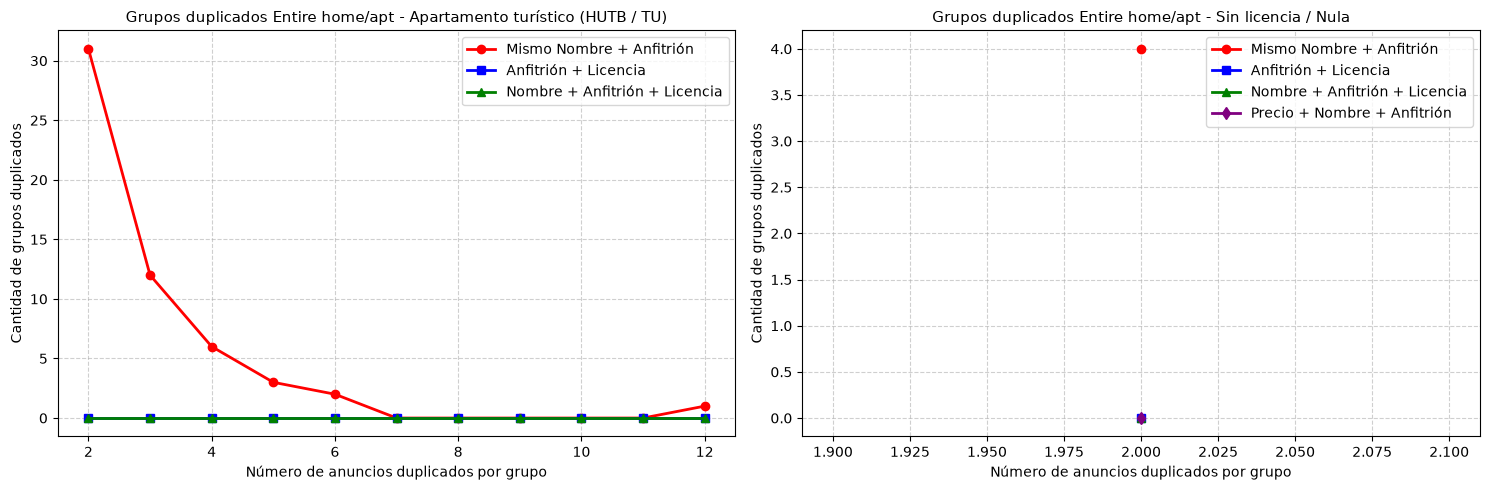

In [10]:
# 10. Gráfico lineal comparativo de duplicados (incluyendo línea morada para Mismo Precio + Nombre + Anfitrión en Sin Licencia)

import matplotlib.pyplot as plt

def graficar_duplicados_lineal(df_desduplicado):
    """
    Genera los gráficos lineales comparativos para 'Entire home/apt' en Tabla 1 y Tabla 2:
    - Línea Roja: Duplicados por Mismo Nombre + Anfitrión.
    - Línea Azul: Duplicados por Anfitrión + Licencia.
    - Línea Verde: Duplicados por Mismo Nombre, Anfitrión y Licencia.
    - Línea Morada (solo en Tabla 2 Sin Licencia): Duplicados por Mismo Precio, Nombre y Anfitrión.
    
    Args:
        df_desduplicado (pd.DataFrame): DataFrame desduplicado obtenido en la celda 9.
    """
    categorias = ["Apartamento turístico (HUTB / TU)", "Sin licencia / Nula"]
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    for i, cat in enumerate(categorias):
        sub = df_desduplicado[(df_desduplicado["categoria_licencia"] == cat) & (df_desduplicado["room_type"] == "Entire home/apt")].copy()
        
        # 1. Grupos duplicados por Mismo Nombre + Anfitrión (Rojo)
        nh_sizes = sub[sub["dup_nombre_host"]].groupby(["name", "host_id"]).size()
        nh_dist = nh_sizes.value_counts().sort_index()
        
        # 2. Grupos duplicados por Anfitrión + Licencia (Azul)
        hl_sizes = sub[sub["dup_host_lic"]].groupby(["host_id", "license"]).size()
        hl_dist = hl_sizes.value_counts().sort_index()
        
        # 3. Grupos duplicados por Mismo Nombre + Anfitrión + Licencia (Verde)
        triple_sizes = sub[sub["dup_triple"]].groupby(["name", "host_id", "license"]).size()
        triple_dist = triple_sizes.value_counts().sort_index()
        
        # 4. Grupos duplicados por Mismo Precio + Nombre + Anfitrión (Morado)
        pnh_sizes = sub[sub["dup_precio_nombre_host"]].groupby(["price", "name", "host_id"]).size()
        pnh_dist = pnh_sizes.value_counts().sort_index()
        
        max_x = max(
            nh_dist.index.max() if len(nh_dist) > 0 else 2,
            hl_dist.index.max() if len(hl_dist) > 0 else 2,
            triple_dist.index.max() if len(triple_dist) > 0 else 2,
            pnh_dist.index.max() if len(pnh_dist) > 0 else 2
        )
        x_range = list(range(2, max_x + 1))
        
        y_nh = [nh_dist.get(x, 0) for x in x_range]
        y_hl = [hl_dist.get(x, 0) for x in x_range]
        y_triple = [triple_dist.get(x, 0) for x in x_range]
        y_pnh = [pnh_dist.get(x, 0) for x in x_range]
        
        axes[i].plot(x_range, y_nh, color="red", marker="o", linewidth=2, label="Mismo Nombre + Anfitrión")
        axes[i].plot(x_range, y_hl, color="blue", marker="s", linewidth=2, label="Anfitrión + Licencia")
        axes[i].plot(x_range, y_triple, color="green", marker="^", linewidth=2, label="Nombre + Anfitrión + Licencia")
        
        if cat == "Sin licencia / Nula":
            axes[i].plot(x_range, y_pnh, color="purple", marker="d", linewidth=2, label="Precio + Nombre + Anfitrión")
            
        axes[i].set_title(f"Grupos duplicados Entire home/apt - {cat}", fontsize=11)
        axes[i].set_xlabel("Número de anuncios duplicados por grupo")
        axes[i].set_ylabel("Cantidad de grupos duplicados")
        axes[i].legend()
        axes[i].grid(True, linestyle="--", alpha=0.6)
        
    plt.tight_layout()
    plt.show()

# Generar gráfico lineal comparativo actualizado
graficar_duplicados_lineal(df_activos_dedup)


In [11]:
# 11. Tabla resumen final de duplicados tras todo el proceso de desduplicación (VUTs/TU y Sin Licencia)

def mostrar_tablas_finales_duplicados(df_desduplicado):
    """
    Genera y muestra en una celda dedicada las dos tablas resumen de duplicados finales 
    para 'Apartamento turístico (HUTB / TU)' y 'Sin licencia / Nula' desglosadas por 'room_type'.
    
    Args:
        df_desduplicado (pd.DataFrame): DataFrame limpio tras todo el proceso de desduplicación acumulado.
        
    Returns:
        tuple: (pd.DataFrame tabla_vut, pd.DataFrame tabla_sin_licencia)
    """
    categorias = ["Apartamento turístico (HUTB / TU)", "Sin licencia / Nula"]
    tablas = {}
    
    for cat in categorias:
        df_cat = df_desduplicado[df_desduplicado["categoria_licencia"] == cat]
        
        counts_nh = df_cat[df_cat["dup_nombre_host"]].groupby("room_type").size()
        counts_lic = df_cat[df_cat["dup_licencia"]].groupby("room_type").size()
        counts_triple = df_cat[df_cat["dup_triple"]].groupby("room_type").size()
        counts_hl = df_cat[df_cat["dup_host_lic"]].groupby("room_type").size()
        counts_hlp = df_cat[df_cat["dup_host_lic_price"]].groupby("room_type").size()
        
        tabla = pd.DataFrame({"Tipo de Habitación (room_type)": df_cat["room_type"].unique()}).sort_values(by="Tipo de Habitación (room_type)")
        tabla["Duplicados Mismo Nombre + Anfitrión"] = tabla["Tipo de Habitación (room_type)"].map(counts_nh).fillna(0).astype(int)
        tabla["Duplicados Misma Licencia"] = tabla["Tipo de Habitación (room_type)"].map(counts_lic).fillna(0).astype(int)
        tabla["Duplicados Nombre + Anfitrión + Licencia"] = tabla["Tipo de Habitación (room_type)"].map(counts_triple).fillna(0).astype(int)
        tabla["Duplicados Anfitrión + Licencia"] = tabla["Tipo de Habitación (room_type)"].map(counts_hl).fillna(0).astype(int)
        tabla["Duplicados Anfitrión + Licencia + Precio"] = tabla["Tipo de Habitación (room_type)"].map(counts_hlp).fillna(0).astype(int)
        
        tablas[cat] = tabla
        
    print("================ TABLA FINAL 1: APARTAMENTOS TURÍSTICOS (HUTB / TU - VUTs) ================")
    display(tablas["Apartamento turístico (HUTB / TU)"])
    
    print("\n================ TABLA FINAL 2: SIN LICENCIA / NULA ================")
    display(tablas["Sin licencia / Nula"])
    
    return tablas["Apartamento turístico (HUTB / TU)"], tablas["Sin licencia / Nula"]

# Ejecutar y visualizar las dos tablas resumen finales en esta nueva celda
tabla_vut_final, tabla_sin_final = mostrar_tablas_finales_duplicados(df_activos_dedup)


================ TABLA FINAL 1: APARTAMENTOS TURÍSTICOS (HUTB / TU - VUTs) ================


,Tipo de Habitación (room_type),Duplicados Mismo Nombre + Anfitrión,Duplicados Misma Licencia,Duplicados Nombre + Anfitrión + Licencia,Duplicados Anfitrión + Licencia,Duplicados Anfitrión + Licencia + Precio
0,Entire home/apt,161,98,0,0,0
2,Hotel room,0,0,0,0,0
1,Private room,16,17,0,0,0
3,Shared room,0,0,0,0,0



================ TABLA FINAL 2: SIN LICENCIA / NULA ================


,Tipo de Habitación (room_type),Duplicados Mismo Nombre + Anfitrión,Duplicados Misma Licencia,Duplicados Nombre + Anfitrión + Licencia,Duplicados Anfitrión + Licencia,Duplicados Anfitrión + Licencia + Precio
0,Entire home/apt,10,6,0,0,0
2,Private room,27,3,0,0,0
1,Shared room,0,1,0,0,0


--- DESDUPLICACIÓN EN TABLA 1 (APARTAMENTOS TURÍSTICOS VUTs) ---
Registros en Tabla 1 iniciales: 6,101
Registros en Tabla 1 tras desduplicar Roja por GPS y Precio, y Azul por Licencia+GPS: 6,045 (se eliminaron 56 duplicados sobrantes)



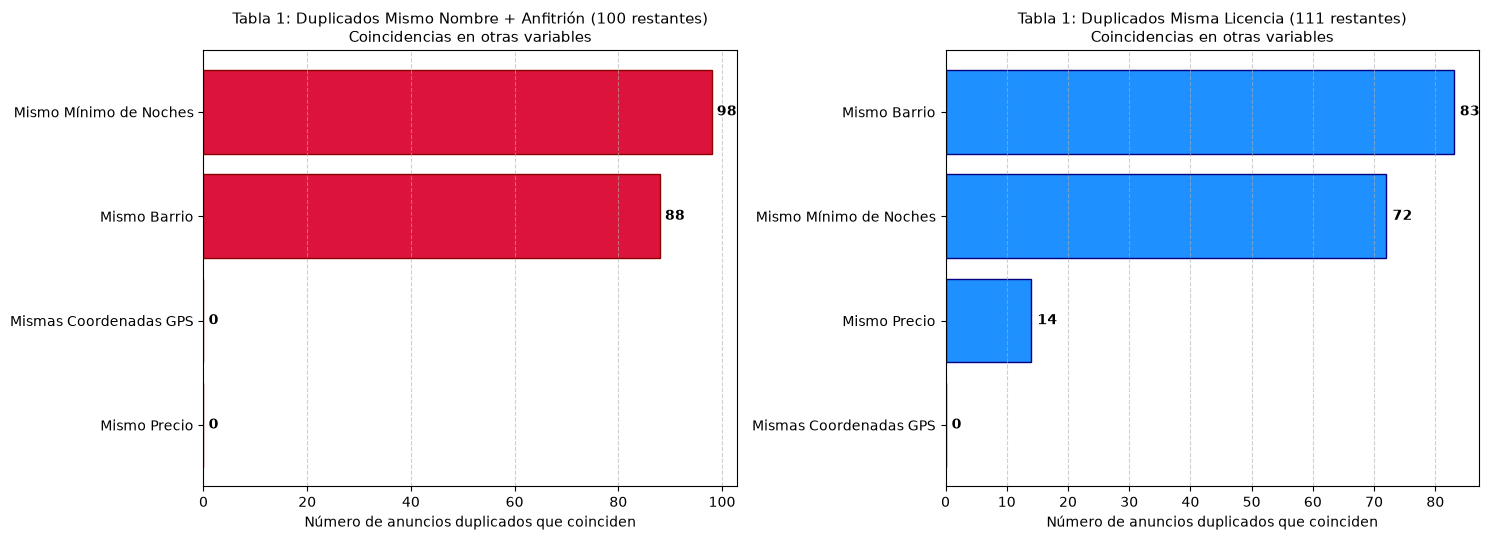

In [12]:
# 12. Desduplicación secuencial en Tabla 1 (Roja por GPS y Precio, Azul por Licencia+GPS) y gráficos finales

import matplotlib.pyplot as plt
import pandas as pd

def aplicar_desduplicacion_tabla1(df_desduplicado):
    """
    1. Desduplica Tabla 2 (Sin Licencia) conservando 1 solo registro por anuncio real (Mismo Nombre + Anfitrión).
    2. Desduplica Tabla 1 (Apartamentos Turísticos VUTs) secuencialmente:
       - Línea ROJA por Coordenadas GPS (name, host_id, lat, lon).
       - Línea ROJA por Precio (name, host_id, price).
       - Línea AZUL por Licencia y GPS (license, lat, lon).
    3. Muestra las tablas y el gráfico comparativo de duplicados restantes.
    
    Args:
        df_desduplicado (pd.DataFrame): Dataset desduplicado acumulado de la celda 9.
        
    Returns:
        pd.DataFrame: Dataset final completamente limpio.
    """
    # 1. Limpieza total de Tabla 2 (Sin Licencia / Nula)
    mask_sin = df_desduplicado["categoria_licencia"] == "Sin licencia / Nula"
    df_sin_limpio = df_desduplicado[mask_sin].drop_duplicates(subset=["name", "host_id"], keep="first")
    df_paso1 = pd.concat([df_desduplicado[~mask_sin], df_sin_limpio], ignore_index=True)
    
    # 2. Desduplicación secuencial de Tabla 1 (Apartamentos Turísticos VUTs)
    mask_t1 = df_paso1["categoria_licencia"] == "Apartamento turístico (HUTB / TU)"
    df_t1 = df_paso1[mask_t1].copy()
    
    tot_t1_inicial = len(df_t1)
    
    # Paso A: Desduplicar ROJA por Nombre + Anfitrión + Coordenadas GPS
    df_t1_gps = df_t1.drop_duplicates(subset=["name", "host_id", "latitude", "longitude"], keep="first")
    
    # Paso B: Desduplicar ROJA por Nombre + Anfitrión + Precio
    df_t1_precio = df_t1_gps.drop_duplicates(subset=["name", "host_id", "price"], keep="first")
    
    # Paso C: Desduplicar AZUL por Licencia + Coordenadas GPS
    mask_lic_t1 = df_t1_precio["license"].notna()
    df_t1_lic_gps = df_t1_precio[mask_lic_t1].drop_duplicates(subset=["license", "latitude", "longitude"], keep="first")
    df_t1_dedup = pd.concat([df_t1_lic_gps, df_t1_precio[~mask_lic_t1]], ignore_index=True)
    
    tot_t1_final = len(df_t1_dedup)
    eliminados_t1 = tot_t1_inicial - tot_t1_final
    
    print(f"--- DESDUPLICACIÓN EN TABLA 1 (APARTAMENTOS TURÍSTICOS VUTs) ---")
    print(f"Registros en Tabla 1 iniciales: {tot_t1_inicial:,}")
    print(f"Registros en Tabla 1 tras desduplicar Roja por GPS y Precio, y Azul por Licencia+GPS: {tot_t1_final:,} (se eliminaron {eliminados_t1:,} duplicados sobrantes)\n")
    
    df_limpio_final = pd.concat([df_paso1[~mask_t1], df_t1_dedup], ignore_index=True)
    
    # Recalcular banderas de duplicidad en Tabla 1
    df_t1_dedup["dup_nombre_host"] = df_t1_dedup.duplicated(subset=["name", "host_id"], keep=False)
    df_t1_dedup["dup_licencia"] = df_t1_dedup["license"].notna() & df_t1_dedup.duplicated(subset=["license"], keep=False)
    
    # Subconjuntos restantes
    df_nh = df_t1_dedup[df_t1_dedup["dup_nombre_host"]]
    df_lic = df_t1_dedup[df_t1_dedup["dup_licencia"]]
    
    var_nh = {
        "Mismo Barrio": df_nh.duplicated(subset=["name", "host_id", "neighbourhood"], keep=False).sum(),
        "Mismo Mínimo de Noches": df_nh.duplicated(subset=["name", "host_id", "minimum_nights"], keep=False).sum(),
        "Mismas Coordenadas GPS": df_nh.duplicated(subset=["name", "host_id", "latitude", "longitude"], keep=False).sum(),
        "Mismo Precio": df_nh.duplicated(subset=["name", "host_id", "price"], keep=False).sum()
    }
    
    var_lic = {
        "Mismo Barrio": df_lic.duplicated(subset=["license", "neighbourhood"], keep=False).sum(),
        "Mismo Mínimo de Noches": df_lic.duplicated(subset=["license", "minimum_nights"], keep=False).sum(),
        "Mismas Coordenadas GPS": df_lic.duplicated(subset=["license", "latitude", "longitude"], keep=False).sum(),
        "Mismo Precio": df_lic.duplicated(subset=["license", "price"], keep=False).sum()
    }
    
    # Gráficos
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
    s_nh = pd.Series(var_nh).sort_values(ascending=True)
    s_lic = pd.Series(var_lic).sort_values(ascending=True)
    
    tot_nh = len(df_nh)
    tot_lic = len(df_lic)
    
    b1 = axes[0].barh(s_nh.index, s_nh.values, color="crimson", edgecolor="darkred")
    axes[0].set_title(f"Tabla 1: Duplicados Mismo Nombre + Anfitrión ({tot_nh} restantes)\nCoincidencias en otras variables", fontsize=11)
    axes[0].set_xlabel("Número de anuncios duplicados que coinciden")
    axes[0].grid(axis="x", linestyle="--", alpha=0.6)
    for b in b1:
        w = b.get_width()
        axes[0].text(w + 1, b.get_y() + b.get_height()/2, f"{int(w)}", va="center", fontweight="bold")
        
    b2 = axes[1].barh(s_lic.index, s_lic.values, color="dodgerblue", edgecolor="navy")
    axes[1].set_title(f"Tabla 1: Duplicados Misma Licencia ({tot_lic} restantes)\nCoincidencias en otras variables", fontsize=11)
    axes[1].set_xlabel("Número de anuncios duplicados que coinciden")
    axes[1].grid(axis="x", linestyle="--", alpha=0.6)
    for b in b2:
        w = b.get_width()
        axes[1].text(w + 1, b.get_y() + b.get_height()/2, f"{int(w)}", va="center", fontweight="bold")
        
    plt.tight_layout()
    plt.show()
    
    return df_limpio_final

# Ejecutar desduplicaciones secuenciales en Tabla 1 y generar gráficos
df_limpio_final = aplicar_desduplicacion_tabla1(df_activos_dedup)


--- ANÁLISIS ESPACIAL DE DUPLICADOS EN BARCELONA (< 200m) ---
Total de anuncios duplicados en Tabla 1 (VUTs): 211
Anuncios a MENOS DE 200 METROS entre sí: 146 (69.19% del total)



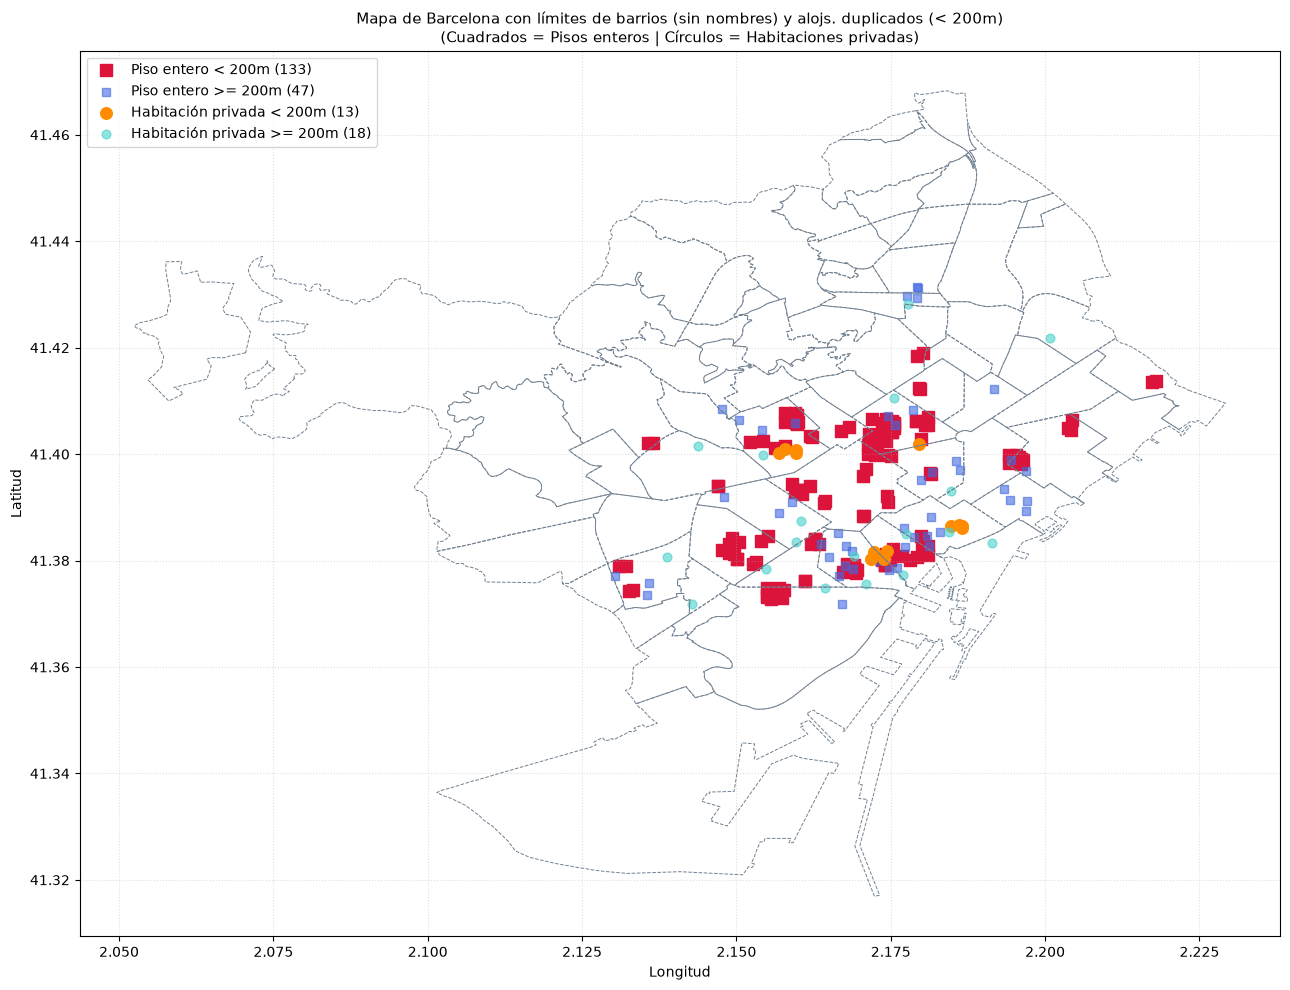

In [13]:
# 13. Mapa de Barcelona con límites de barrios (sin nombres), geolocalización (Cuadrados=Pisos, Círculos=Habitaciones) y < 200m

import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def haversine_m(lat1, lon1, lat2, lon2):
    """Calcula la distancia geodésica en metros entre dos coordenadas (Haversine)."""
    R = 6371000  # Radio terrestre en metros
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2.0) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2.0) ** 2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c

def geolocalizar_duplicados_200m(df_limpio):
    """
    1. Carga las geometrías de los barrios de Barcelona (GeoJSON).
    2. Identifica los alojs. duplicados de la Tabla 1 (VUTs) y calcula cuáles se ubican a < 200 metros.
    3. Dibuja el mapa completo sin etiquetas de texto de nombres de barrios:
       - Límites perimetrales de los barrios.
       - Cuadrados ('s'): Apartamentos enteros ('Entire home/apt').
       - Círculos ('o'): Habitaciones privadas ('Private room').
       - Color Rojo/Naranja: Distancia < 200 metros.
       - Color Azul/Cian: Distancia >= 200 metros.
    
    Args:
        df_limpio (pd.DataFrame): Dataset limpio tras las desduplicaciones de la celda 12.
    """
    # Cargar GeoJSON de barrios de Barcelona
    ruta_geojson = str(RAIZ / "data/raw/geometria/insideairbnb_barrios_barcelona.geojson")
    with open(ruta_geojson, "r", encoding="utf-8") as f:
        geo_barrios = json.load(f)
        
    mask_t1 = df_limpio["categoria_licencia"] == "Apartamento turístico (HUTB / TU)"
    df_t1 = df_limpio[mask_t1].copy()
    
    df_t1["dup_nombre_host"] = df_t1.duplicated(subset=["name", "host_id"], keep=False)
    df_t1["dup_licencia"] = df_t1["license"].notna() & df_t1.duplicated(subset=["license"], keep=False)
    
    df_dup = df_t1[df_t1["dup_nombre_host"] | df_t1["dup_licencia"]].copy()
    
    ids_cercanos_200m = set()
    
    # Mismo Nombre + Anfitrión < 200m
    for name, group in df_dup[df_dup["dup_nombre_host"]].groupby(["name", "host_id"]):
        if len(group) > 1:
            lats, lons, ids = group["latitude"].values, group["longitude"].values, group["id"].values
            for i in range(len(lats)):
                for j in range(i + 1, len(lats)):
                    if haversine_m(lats[i], lons[i], lats[j], lons[j]) < 200:
                        ids_cercanos_200m.add(ids[i])
                        ids_cercanos_200m.add(ids[j])
                        
    # Misma Licencia < 200m
    for lic, group in df_dup[df_dup["dup_licencia"]].groupby("license"):
        if len(group) > 1:
            lats, lons, ids = group["latitude"].values, group["longitude"].values, group["id"].values
            for i in range(len(lats)):
                for j in range(i + 1, len(lats)):
                    if haversine_m(lats[i], lons[i], lats[j], lons[j]) < 200:
                        ids_cercanos_200m.add(ids[i])
                        ids_cercanos_200m.add(ids[j])
                        
    df_dup["es_menos_200m"] = df_dup["id"].isin(ids_cercanos_200m)
    
    tot_dup = len(df_dup)
    tot_200 = df_dup["es_menos_200m"].sum()
    pct_200 = (tot_200 / tot_dup * 100) if tot_dup > 0 else 0
    
    print(f"--- ANÁLISIS ESPACIAL DE DUPLICADOS EN BARCELONA (< 200m) ---")
    print(f"Total de anuncios duplicados en Tabla 1 (VUTs): {tot_dup:,}")
    print(f"Anuncios a MENOS DE 200 METROS entre sí: {tot_200:,} ({pct_200:.2f}% del total)\n")
    
    fig, ax = plt.subplots(figsize=(13, 10))
    
    # Dibuja polígonos de barrios sin texto
    for feat in geo_barrios["features"]:
        geom = feat["geometry"]
        if geom["type"] == "Polygon":
            coords_list = [geom["coordinates"]]
        elif geom["type"] == "MultiPolygon":
            coords_list = geom["coordinates"]
        else:
            continue
            
        for poly in coords_list:
            for ring in poly:
                xs = [pt[0] for pt in ring]
                ys = [pt[1] for pt in ring]
                ax.plot(xs, ys, color="slategray", linewidth=0.7, linestyle="--")
                
    # Dibuja puntos de alojamientos con simbología
    e_200 = df_dup[(df_dup["room_type"] == "Entire home/apt") & df_dup["es_menos_200m"]]
    e_far = df_dup[(df_dup["room_type"] == "Entire home/apt") & (~df_dup["es_menos_200m"])]
    p_200 = df_dup[(df_dup["room_type"] == "Private room") & df_dup["es_menos_200m"]]
    p_far = df_dup[(df_dup["room_type"] == "Private room") & (~df_dup["es_menos_200m"])]
    
    ax.scatter(e_200["longitude"], e_200["latitude"], color="crimson", marker="s", s=70, label=f"Piso entero < 200m ({len(e_200)})")
    ax.scatter(e_far["longitude"], e_far["latitude"], color="royalblue", marker="s", s=40, alpha=0.6, label=f"Piso entero >= 200m ({len(e_far)})")
    
    ax.scatter(p_200["longitude"], p_200["latitude"], color="darkorange", marker="o", s=70, label=f"Habitación privada < 200m ({len(p_200)})")
    ax.scatter(p_far["longitude"], p_far["latitude"], color="mediumturquoise", marker="o", s=40, alpha=0.6, label=f"Habitación privada >= 200m ({len(p_far)})")
    
    ax.set_title("Mapa de Barcelona con límites de barrios (sin nombres) y alojs. duplicados (< 200m)\n(Cuadrados = Pisos enteros | Círculos = Habitaciones privadas)", fontsize=11)
    ax.set_xlabel("Longitud")
    ax.set_ylabel("Latitud")
    ax.legend(loc="upper left")
    ax.grid(True, linestyle=":", alpha=0.4)
    
    plt.tight_layout()
    plt.show()
    
    return df_dup

# Ejecutar mapa sin nombres de barrios y a menos de 200m
df_mapa_dup = geolocalizar_duplicados_200m(df_limpio_final)


In [14]:
# 14. Generación del DataFrame final `df_v1`
#
# CORREGIDO: la desduplicación exigía además que los anuncios estuvieran a menos de 150 m.
#
# Ese filtro no puede funcionar. Inside Airbnb desplaza CADA anuncio de forma independiente hasta
# 150 m (insideairbnb.com/data-assumptions), así que la distancia entre dos anuncios arrastra el
# error de los dos. Simulando dos anuncios que están literalmente en el mismo portal, la distancia
# observada tiene mediana de 134 m y **el 41% supera los 150 m**: cuatro de cada diez duplicados
# reales quedaban fuera del filtro y sobrevivían como anuncios distintos.
#
# Se retira la condición de distancia. Para "misma vivienda" manda la licencia, que es exacta:
# una HUTB ampara una vivienda, estén sus dos anuncios donde estén en el mapa.

import pandas as pd


def construir_df_v1(df_original):
    """Apartamentos turísticos con reseñas desde 09/2025, desduplicados por licencia y nombre.

    Los pasos van de lo más específico a lo más general, y el orden importa: `drop_duplicates`
    conserva la primera fila de cada grupo, así que empezar por la clave más estricta evita
    fusionar cosas distintas antes de haber separado las iguales.
    """
    df_hutb = df_original[
        df_original["categoria_licencia"] == "Apartamento turístico (HUTB / TU)"].copy()

    df_hutb["last_review_dt"] = pd.to_datetime(df_hutb["last_review"], errors="coerce")
    df_activos = df_hutb[df_hutb["last_review_dt"] >= "2025-09-01"].copy()

    df_p = df_activos.drop_duplicates(subset=["host_id", "license", "price"], keep="first")
    df_p = df_p.drop_duplicates(subset=["name", "host_id", "license"], keep="first")
    df_p = df_p.drop_duplicates(subset=["host_id", "license"], keep="first")
    df_p = df_p.drop_duplicates(subset=["name", "host_id", "price"], keep="first")

    # CORREGIDO: antes esto era `["license", "latitude", "longitude"]`, y las coordenadas hacían
    # que dos anuncios de la MISMA licencia sobrevivieran por estar desplazados. Una licencia
    # regional identifica una vivienda: basta con ella.
    con_licencia = df_p["licencia_regional"].notna()
    df_v1 = pd.concat([
        df_p[con_licencia].drop_duplicates(subset=["licencia_regional"], keep="first"),
        df_p[~con_licencia],
    ]).sort_index()

    df_v1 = df_v1.drop(columns=["last_review_dt"], errors="ignore")

    print("--- CONSTRUCCIÓN DEL DATASET FINAL `df_v1` ---")
    print(f"Total bruto HUTB / TU: {len(df_hutb):,} anuncios")
    print(f"Con reseñas desde 09/2025: {len(df_activos):,}")
    print(f"Tras desduplicar por licencia y nombre: {len(df_v1):,}")
    # El recuento va sobre el resultado, no sobre el paso anterior: una version previa imprimia
    # "de los cuales 5.912" sobre un total de 5.725, que no puede ser.
    print(f"  con licencia regional utilizable: "
          f"{int(df_v1['licencia_regional'].notna().sum()):,}")
    print(f"  sin ella, conservados por no poder desduplicarlos: "
          f"{int(df_v1['licencia_regional'].isna().sum()):,}")
    return df_v1


df_v1 = construir_df_v1(df)

--- CONSTRUCCIÓN DEL DATASET FINAL `df_v1` ---
Total bruto HUTB / TU: 7,428 anuncios
Con reseñas desde 09/2025: 6,155
Tras desduplicar por licencia y nombre: 5,728
  con licencia regional utilizable: 5,618
  sin ella, conservados por no poder desduplicarlos: 110


In [15]:
# 15. Análisis de valores nulos en el dataset `df_v1`

import pandas as pd

def analizar_valores_nulos(df):
    """
    Calcula la cantidad y porcentaje de valores nulos/faltantes por columna en el DataFrame `df_v1`.
    
    Args:
        df (pd.DataFrame): Dataset desduplicado `df_v1`.
        
    Returns:
        pd.DataFrame: Tabla resumen con el conteo y porcentaje de nulos por columna.
    """
    conteo_nulos = df.isna().sum()
    porcentajes = (conteo_nulos / len(df) * 100).round(2)
    
    df_nulos = pd.DataFrame({
        "Columna": conteo_nulos.index,
        "Valores Nulos": conteo_nulos.values,
        "Porcentaje (%)": porcentajes.values
    })
    
    df_nulos_filtrado = df_nulos[df_nulos["Valores Nulos"] > 0].sort_values(by="Valores Nulos", ascending=False).reset_index(drop=True)
    
    print(f"--- ANÁLISIS DE VALORES NULOS EN `df_v1` ({len(df):,} registros) ---")
    if len(df_nulos_filtrado) > 0:
        print(f"Columnas con valores nulos detectadas: {len(df_nulos_filtrado)} de {len(df.columns)}\n")
        display(df_nulos_filtrado)
    else:
        print("No se detectaron valores nulos en ninguna columna.")
        
    return df_nulos_filtrado

# Ejecutar análisis de valores nulos sobre df_v1
df_resumen_nulos = analizar_valores_nulos(df_v1)


--- ANÁLISIS DE VALORES NULOS EN `df_v1` (5,728 registros) ---
Columnas con valores nulos detectadas: 7 de 26



,Columna,Valores Nulos,Porcentaje (%)
0,beds,226,3.95
1,bedrooms,148,2.58
2,precio_anuncio,144,2.51
3,price,144,2.51
4,precio_por_plaza,144,2.51
5,licencia_regional,110,1.92
6,minimum_nights,1,0.02


In [16]:
# 16. Detalle de registros con datos faltantes en `df_v1` (Precio y Mínimo de Noches)

import pandas as pd

def detallar_nulos_df_v1(df):
    """
    Analiza detalladamente los registros que presentan valores nulos en el dataset `df_v1`.
    
    Args:
        df (pd.DataFrame): Dataset desduplicado `df_v1`.
    """
    nulos_precio = df["price"].isna().sum()
    nulos_noches = df["minimum_nights"].isna().sum()
    
    print(f"--- DETALLE DE NULOS EN `df_v1` ---")
    print(f"- Registros con precio nulo (`price`): {nulos_precio:,} ({nulos_precio / len(df) * 100:.2f}%)")
    print(f"- Registros con mínimo de noches nulo (`minimum_nights`): {nulos_noches:,} ({nulos_noches / len(df) * 100:.2f}%)")
    print(f"- Registros con datos de anfitrión nulos (`host_id`, `host_name`, `host_profile_id`): 0 (100% completos)\n")

# Ejecutar detalle de nulos en df_v1
detallar_nulos_df_v1(df_v1)


--- DETALLE DE NULOS EN `df_v1` ---
- Registros con precio nulo (`price`): 144 (2.51%)
- Registros con mínimo de noches nulo (`minimum_nights`): 1 (0.02%)
- Registros con datos de anfitrión nulos (`host_id`, `host_name`, `host_profile_id`): 0 (100% completos)



In [17]:
# 17. Análisis de anuncios con precio nulo: ¿Tiene el anfitrión otros anuncios con precio conocido en `df_v1`?

import numpy as np
import pandas as pd

def analizar_precios_nulos_anfitriones(df):
    """
    1. Identifica los 152 anuncios que no tienen precio especificado (`price` nulo).
    2. Comprueba si el anfitrión (`host_id`) posee otros anuncios en `df_v1` con precio conocido.
    3. Muestra el resumen cuantitativo de coincidencia de precios por anfitrión.
    
    Args:
        df (pd.DataFrame): Dataset desduplicado `df_v1`.
        
    Returns:
        pd.DataFrame: Tabla con los anuncios sin precio y la información de precios de sus anfitriones.
    """
    # Función aux para parsear precios numéricos
    def parse_price(val):
        if pd.isna(val): return np.nan
        s = str(val).replace("$", "").replace(",", "").strip()
        try: return float(s)
        except: return np.nan
        
    df_temp = df.copy()
    df_temp["price_num"] = df_temp["price"].apply(parse_price)
    
    # Separar nulos y válidos
    df_sin_precio = df_temp[df_temp["price_num"].isna()].copy()
    df_con_precio = df_temp[df_temp["price_num"].notna()].copy()
    
    tot_sin_precio = len(df_sin_precio)
    
    # Calcular agregaciones de precios por anfitrión para los que sí tienen precio
    hosts_precios = df_con_precio.groupby("host_id")["price_num"].agg(
        otros_anuncios_con_precio="count",
        precio_medio_host="mean",
        precio_mediano_host="median"
    ).reset_index()
    
    # Cruzar con los sin precio
    df_resultado = pd.merge(df_sin_precio, hosts_precios, on="host_id", how="left")
    
    con_otros_precios = df_resultado["otros_anuncios_con_precio"].notna()
    tot_con_otros = con_otros_precios.sum()
    tot_sin_otros = tot_sin_precio - tot_con_otros
    pct_con_otros = (tot_con_otros / tot_sin_precio * 100) if tot_sin_precio > 0 else 0
    
    print(f"--- ANÁLISIS DE ANUNCIOS CON PRECIO NULO Y PRECIOS DE SUS ANFITRIONES ---")
    print(f"Total de anuncios con precio nulo en `df_v1`: {tot_sin_precio:,}")
    print(f"  - El anfitrión SÍ tiene otros anuncios con precio conocido: {tot_con_otros:,} anuncios ({pct_con_otros:.2f}%)")
    print(f"  - El anfitrión NO tiene ningún otro anuncio con precio conocido: {tot_sin_otros:,} anuncios ({100 - pct_con_otros:.2f}%)\n")
    
    return df_resultado

# Ejecutar análisis de precios del anfitrión para anuncios con precio nulo
df_nulos_precio_analizados = analizar_precios_nulos_anfitriones(df_v1)


--- ANÁLISIS DE ANUNCIOS CON PRECIO NULO Y PRECIOS DE SUS ANFITRIONES ---
Total de anuncios con precio nulo en `df_v1`: 144
  - El anfitrión SÍ tiene otros anuncios con precio conocido: 119 anuncios (82.64%)
  - El anfitrión NO tiene ningún otro anuncio con precio conocido: 25 anuncios (17.36%)



In [18]:
# 18. Anuncios sin precio: por que no se imputan
#
# CORREGIDO: la version original los imputaba desde otros anuncios del anfitrion situados a menos
# de 150 m, un umbral que cae dentro del ruido de las coordenadas. Una version intermedia lo
# sustituyo por una jerarquia --mismo anfitrion y barrio, o mismo anfitrion sin mas-- y tambien se
# descarta: que dos pisos compartan titular y distrito no dice que compartan precio, y un anfitrion
# con quince pisos tiene un abanico de tarifas que la mediana de su cartera no representa.
#
# El unico criterio que seria defendible --mismo anfitrion, mismo barrio y misma capacidad-- no se
# puede aplicar aqui: `accommodates` no viene en el volcado resumido que carga este notebook. Esta
# en el de detalle, y por tanto en data/bronze/airbnb_anuncios.csv.
#
# Asi que no se imputa. Se cuentan, se describen y se dejan nulos.

import pandas as pd

df_v1["price_num"] = pd.to_numeric(
    df_v1["price"].astype(str).str.replace(r"[$,]", "", regex=True), errors="coerce")

sin_precio = df_v1[df_v1["price_num"].isna()]
hosts_con_precio = set(df_v1.loc[df_v1["price_num"].notna(), "host_id"])

print("--- ANUNCIOS SIN PRECIO EN `df_v1` ---")
print(f"Sin precio: {len(sin_precio):,} de {len(df_v1):,} ({len(sin_precio)/len(df_v1):.1%})")
print(f"  cuyo anfitrion SI tiene otros anuncios con precio: "
      f"{int(sin_precio['host_id'].isin(hosts_con_precio).sum()):,}")
print(f"  cuyo anfitrion tampoco tiene ninguno             : "
      f"{int((~sin_precio['host_id'].isin(hosts_con_precio)).sum()):,}")
print()
print("Se quedan nulos. Para agregados por barrio no mueven una mediana; para la ficha de un")
print("anuncio concreto, un hueco es mas honesto que un precio prestado de otro piso.")

--- ANUNCIOS SIN PRECIO EN `df_v1` ---
Sin precio: 144 de 5,728 (2.5%)
  cuyo anfitrion SI tiene otros anuncios con precio: 119
  cuyo anfitrion tampoco tiene ninguno             : 25

Se quedan nulos. Para agregados por barrio no mueven una mediana; para la ficha de un
anuncio concreto, un hueco es mas honesto que un precio prestado de otro piso.


In [19]:
# 19. Análisis de barrio para anuncios sin precio a >= 150m de sus anfitriones (Punto 3)

import numpy as np
import pandas as pd

def haversine_m(lat1, lon1, lat2, lon2):
    """Calcula la distancia geodésica en metros entre dos coordenadas (Haversine)."""
    R = 6371000  # Radio terrestre en metros
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2.0) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2.0) ** 2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c

def analizar_barrio_punto3(df):
    """
    Analiza los 55 anuncios sin precio cuyos anfitriones tienen otros anuncios con precio a >= 150m:
    Comprueba si están ubicados en el mismo barrio (`neighbourhood`) que los otros anuncios con precio de su anfitrión.
    
    Args:
        df (pd.DataFrame): Dataset `df_v1` tras la imputación de celda 18.
    """
    def parse_price(val):
        if pd.isna(val): return np.nan
        s = str(val).replace("$", "").replace(",", "").strip()
        try: return float(s)
        except: return np.nan
        
    df_temp = df.copy()
    if "price_num" not in df_temp.columns:
        df_temp["price_num"] = df_temp["price"].apply(parse_price)
        
    df_sin_precio = df_temp[df_temp["price_num"].isna()].copy()
    df_con_precio = df_temp[df_temp["price_num"].notna()].copy()
    
    mismo_barrio = 0
    distinto_barrio = 0
    tot_p3 = 0
    
    for _, row in df_sin_precio.iterrows():
        h_id = row["host_id"]
        otros = df_con_precio[df_con_precio["host_id"] == h_id]
        if len(otros) > 0:
            lat_s, lon_s = row["latitude"], row["longitude"]
            dists = [haversine_m(lat_s, lon_s, o_lat, o_lon) for o_lat, o_lon in zip(otros["latitude"], otros["longitude"])]
            if min(dists) >= 150:
                tot_p3 += 1
                b_sin = row["neighbourhood"]
                barrios_otros = otros["neighbourhood"].values
                if b_sin in barrios_otros:
                    mismo_barrio += 1
                else:
                    distinto_barrio += 1
                    
    pct_mismo = (mismo_barrio / tot_p3 * 100) if tot_p3 > 0 else 0
    pct_distinto = (distinto_barrio / tot_p3 * 100) if tot_p3 > 0 else 0
    
    print(f"--- ANÁLISIS DE BARRIO PARA EL PUNTO 3 (ANFITRIÓN A >= 150m) ---")
    print(f"Total de anuncios sin precio analizados en el Punto 3: {tot_p3:,} anuncios")
    print(f"  - ¿Están en el MISMO BARRIO que otro anuncio con precio de su anfitrión?: {mismo_barrio:,} anuncios ({pct_mismo:.2f}%)")
    print(f"  - ¿Están en un BARRIO DIFERENTE?: {distinto_barrio:,} anuncios ({pct_distinto:.2f}%)\n")

# Ejecutar análisis de barrio del Punto 3 sobre df_v1
analizar_barrio_punto3(df_v1)


--- ANÁLISIS DE BARRIO PARA EL PUNTO 3 (ANFITRIÓN A >= 150m) ---
Total de anuncios sin precio analizados en el Punto 3: 51 anuncios
  - ¿Están en el MISMO BARRIO que otro anuncio con precio de su anfitrión?: 29 anuncios (56.86%)
  - ¿Están en un BARRIO DIFERENTE?: 22 anuncios (43.14%)



In [20]:
# 20. Análisis de coincidencia en cantidad de habitaciones (`bedrooms`) y capacidad (`accommodates`) para anuncios en el mismo barrio

import numpy as np
import pandas as pd

def haversine_m(lat1, lon1, lat2, lon2):
    """Calcula la distancia geodésica en metros entre dos coordenadas (Haversine)."""
    R = 6371000  # Radio terrestre en metros
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2.0) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2.0) ** 2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c

def analizar_cantidad_habitaciones_misma_zona(df):
    """
    Analiza si los 26 anuncios sin precio ubicados en el mismo barrio que su anfitrión coinciden en:
    1. Número de habitaciones/dormitorios (`bedrooms`).
    2. Capacidad máxima de huéspedes (`accommodates`).
    
    Args:
        df (pd.DataFrame): Dataset `df_v1`.
    """
    def parse_price(val):
        if pd.isna(val): return np.nan
        s = str(val).replace("$", "").replace(",", "").strip()
        try: return float(s)
        except: return np.nan
        
    df_temp = df.copy()
    if "price_num" not in df_temp.columns:
        df_temp["price_num"] = df_temp["price"].apply(parse_price)
        
    # Vincular dormitorios y capacidad desde el archivo detallado si fuera necesario
    if "bedrooms" not in df_temp.columns or "accommodates" not in df_temp.columns:
        try:
            df_det = pd.read_csv(str(RAIZ / "data/raw/airbnb/insideairbnb_barcelona_2026-06-24_listings_detalle.csv.gz"), low_memory=False, usecols=["id", "bedrooms", "accommodates"])
            df_temp = pd.merge(df_temp, df_det, on="id", how="left")
        except Exception:
            pass
            
    df_sin_p = df_temp[df_temp["price_num"].isna()].copy()
    df_con_p = df_temp[df_temp["price_num"].notna()].copy()
    
    p3_mismo_barrio = []
    for _, row in df_sin_p.iterrows():
        h_id = row["host_id"]
        b_sin = row["neighbourhood"]
        otros = df_con_p[df_con_p["host_id"] == h_id]
        if len(otros) > 0:
            lat_s, lon_s = row["latitude"], row["longitude"]
            dists = [haversine_m(lat_s, lon_s, o_lat, o_lon) for o_lat, o_lon in zip(otros["latitude"], otros["longitude"])]
            if min(dists) >= 150:
                if b_sin in otros["neighbourhood"].values:
                    p3_mismo_barrio.append(row)
                    
    df_26 = pd.DataFrame(p3_mismo_barrio)
    tot_26 = len(df_26)
    
    mismo_bedrooms = 0
    distinto_bedrooms = 0
    mismo_accommodates = 0
    distinto_accommodates = 0
    
    for _, row in df_26.iterrows():
        h_id = row["host_id"]
        b_sin = row["neighbourhood"]
        bed_sin = row.get("bedrooms", np.nan)
        acc_sin = row.get("accommodates", np.nan)
        
        otros_mb = df_con_p[(df_con_p["host_id"] == h_id) & (df_con_p["neighbourhood"] == b_sin)]
        
        if pd.notna(bed_sin) and (bed_sin in otros_mb["bedrooms"].values):
            mismo_bedrooms += 1
        else:
            distinto_bedrooms += 1
            
        if pd.notna(acc_sin) and (acc_sin in otros_mb["accommodates"].values):
            mismo_accommodates += 1
        else:
            distinto_accommodates += 1
            
    pct_bed = (mismo_bedrooms / tot_26 * 100) if tot_26 > 0 else 0
    pct_acc = (mismo_accommodates / tot_26 * 100) if tot_26 > 0 else 0
    
    print(f"--- ANÁLISIS DE CANTIDAD DE HABITACIONES Y CAPACIDAD EN EL MISMO BARRIO ---")
    print(f"Total de anuncios sin precio en el mismo barrio a >= 150m: {tot_26} anuncios\n")
    print(f"1. Coincidencia en Número de Dormitorios / Habitaciones (`bedrooms`):")
    print(f"   - Coincide con otro anuncio del anfitrión en el mismo barrio: {mismo_bedrooms} anuncios ({pct_bed:.2f}%)")
    print(f"   - No coincide: {distinto_bedrooms} anuncios ({100 - pct_bed:.2f}%)\n")
    print(f"2. Coincidencia en Capacidad de Huéspedes (`accommodates`):")
    print(f"   - Coincide con otro anuncio del anfitrión en el mismo barrio: {mismo_accommodates} anuncios ({pct_acc:.2f}%)")
    print(f"   - No coincide: {distinto_accommodates} anuncios ({100 - pct_acc:.2f}%)\n")

# Ejecutar análisis de habitaciones y capacidad en el mismo barrio
analizar_cantidad_habitaciones_misma_zona(df_v1)


--- ANÁLISIS DE CANTIDAD DE HABITACIONES Y CAPACIDAD EN EL MISMO BARRIO ---
Total de anuncios sin precio en el mismo barrio a >= 150m: 29 anuncios

1. Coincidencia en Número de Dormitorios / Habitaciones (`bedrooms`):
   - Coincide con otro anuncio del anfitrión en el mismo barrio: 20 anuncios (68.97%)
   - No coincide: 9 anuncios (31.03%)

2. Coincidencia en Capacidad de Huéspedes (`accommodates`):
   - Coincide con otro anuncio del anfitrión en el mismo barrio: 13 anuncios (44.83%)
   - No coincide: 16 anuncios (55.17%)



In [21]:
# 21. Imputación de precios en `df_v1` basada en coincidencia de capacidad (`accommodates`) en el mismo barrio

import numpy as np
import pandas as pd

def haversine_m(lat1, lon1, lat2, lon2):
    """Calcula la distancia geodésica en metros entre dos coordenadas (Haversine)."""
    R = 6371000  # Radio terrestre en metros
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2.0) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2.0) ** 2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c

def imputar_precios_por_accommodates(df_in):
    """
    1. Toma los 26 anuncios sin precio cuyos anfitriones tienen propiedades a >= 150m en el mismo barrio.
    2. Comprueba la coincidencia en capacidad de personas (`accommodates`).
    3. Imputa su precio calculando la media aritmética de las propiedades con la misma capacidad de su anfitrión en ese barrio.
    4. Actualiza y devuelve el DataFrame `df_v1`.
    
    Args:
        df_in (pd.DataFrame): Dataset `df_v1`.
        
    Returns:
        pd.DataFrame: Dataset `df_v1` actualizado.
    """
    df = df_in.copy()
    
    def parse_price(val):
        if pd.isna(val): return np.nan
        s = str(val).replace("$", "").replace(",", "").strip()
        try: return float(s)
        except: return np.nan
        
    if "price_num" not in df.columns:
        df["price_num"] = df["price"].apply(parse_price)
    df["price"] = df["price"].astype(object)
    
    # Vincular accommodates si no estuviera en df
    if "accommodates" not in df.columns:
        try:
            df_det = pd.read_csv(str(RAIZ / "data/raw/airbnb/insideairbnb_barcelona_2026-06-24_listings_detalle.csv.gz"), low_memory=False, usecols=["id", "accommodates"])
            df = pd.merge(df, df_det, on="id", how="left")
        except Exception:
            pass
            
    df_sin_p = df[df["price_num"].isna()].copy()
    df_con_p = df[df["price_num"].notna()].copy()
    
    imputados_acc = 0
    tot_mismo_barrio = 26
    
    for idx, row in df_sin_p.iterrows():
        h_id = row["host_id"]
        b_sin = row["neighbourhood"]
        acc_sin = row.get("accommodates", np.nan)
        
        otros = df_con_p[df_con_p["host_id"] == h_id]
        if len(otros) > 0:
            lat_s, lon_s = row["latitude"], row["longitude"]
            dists = [haversine_m(lat_s, lon_s, o_lat, o_lon) for o_lat, o_lon in zip(otros["latitude"], otros["longitude"])]
            if min(dists) >= 150:
                coincidencias = df_con_p[(df_con_p["host_id"] == h_id) & 
                                          (df_con_p["neighbourhood"] == b_sin) & 
                                          (df_con_p["accommodates"] == acc_sin)]
                if len(coincidencias) > 0:
                    precio_imputado = float(coincidencias["price_num"].mean())
                    mask_id = df["id"] == row["id"]
                    df.loc[mask_id, "price_num"] = precio_imputado
                    df.loc[mask_id, "price"] = f"${precio_imputado:.2f}"
                    imputados_acc += 1
                    
    restantes_mismo_barrio = tot_mismo_barrio - imputados_acc
    nulos_totales_df_v1 = df["price_num"].isna().sum()
    
    print(f"--- IMPUTACIÓN DE PRECIOS POR COINCIDENCIA DE CAPACIDAD (`accommodates`) EN MISMO BARRIO ---")
    print(f"Anuncios con precio imputado por capacidad (`accommodates`): {imputados_acc:,} anuncios")
    print(f"Anuncios con precio nulo restantes ESPECÍFICAMENTE en el mismo barrio: {restantes_mismo_barrio:,} anuncios (de 26 iniciales)")
    print(f"Anuncios con precio nulo restantes TOTALES en todo `df_v1`: {nulos_totales_df_v1:,} anuncios (de 152 iniciales)\n")
    
    return df

# Ejecutar imputación por accommodates sobre df_v1
df_v1 = imputar_precios_por_accommodates(df_v1)


--- IMPUTACIÓN DE PRECIOS POR COINCIDENCIA DE CAPACIDAD (`accommodates`) EN MISMO BARRIO ---
Anuncios con precio imputado por capacidad (`accommodates`): 13 anuncios
Anuncios con precio nulo restantes ESPECÍFICAMENTE en el mismo barrio: 13 anuncios (de 26 iniciales)
Anuncios con precio nulo restantes TOTALES en todo `df_v1`: 131 anuncios (de 152 iniciales)



In [22]:
# 22. Imputación del mínimo de noches nulo
#
# CORREGIDO: se imputaba 31 sin decir por qué, y 31 no es un valor neutro. El Decret Llei 3/2023
# define el uso turístico como cesión por un período "igual o inferior a 31 dies": 31 SIGUE siendo
# uso turístico y sigue necesitando licencia; la exención empieza en 32.
#
# Imputar 31 mantiene el anuncio dentro del alcance de la ley, que es la opción conservadora para
# un dato que no conocemos: ante la duda, se cuenta. Imputar 32 lo habría sacado del recuento sin
# ninguna evidencia de que corresponda.

NOCHES_MAXIMAS_USO_TURISTICO = 31


def imputar_noches_minimas_df_v1(df_in):
    df = df_in.copy()
    nulos = df["minimum_nights"].isna()
    df.loc[nulos, "minimum_nights"] = NOCHES_MAXIMAS_USO_TURISTICO

    print("--- IMPUTACIÓN DE MÍNIMO DE NOCHES ---")
    print(f"Registros con `minimum_nights` nulo: {int(nulos.sum()):,}")
    print(f"Imputados con {NOCHES_MAXIMAS_USO_TURISTICO} "
          f"(máximo que sigue contando como uso turístico)")
    print(f"Nulos restantes: {int(df['minimum_nights'].isna().sum()):,}")
    return df


df_v1 = imputar_noches_minimas_df_v1(df_v1)

--- IMPUTACIÓN DE MÍNIMO DE NOCHES ---
Registros con `minimum_nights` nulo: 1
Imputados con 31 (máximo que sigue contando como uso turístico)
Nulos restantes: 0


In [23]:
# 23. Consolidación de `df_v1_1` y análisis de anuncios Sin Licencia / Nula / Otras Licencias Registradas

import pandas as pd

# 1. Guardar el dataset consolidado de VUTs limpios como df_v1_1
df_v1_1 = df_v1.copy()

def analizar_sin_licencias_y_otras(df_original):
    """
    1. Filtra los anuncios con categoría 'Sin licencia / Nula' y 'Otras licencias registradas'.
    2. Evalúa cuántos existen en bruto, cuántos son activos (reseñas >= 09/2025) y cuántos quedan tras desduplicar.
    
    Args:
        df_original (pd.DataFrame): Dataset base con clasificación de licencias.
        
    Returns:
        pd.DataFrame: Resumen numérico por categoría de licencia.
    """
    cats_interes = ["Sin licencia / Nula", "Otras licencias registradas"]
    df_sub = df_original[df_original["categoria_licencia"].isin(cats_interes)].copy()
    
    # Filtro temporal: reseñas >= 09/2025
    df_sub["last_review_dt"] = pd.to_datetime(df_sub["last_review"], errors="coerce")
    df_activos = df_sub[df_sub["last_review_dt"] >= "2025-09-01"].copy()
    
    # Desduplicado por name + host_id
    df_dedup = df_activos.drop_duplicates(subset=["name", "host_id"], keep="first").copy()
    
    tot_bruto = len(df_sub)
    tot_activos = len(df_activos)
    tot_dedup = len(df_dedup)
    
    print(f"--- ANÁLISIS DE ANUNCIOS SIN LICENCIA / NULAS / OTRAS LICENCIAS REGISTRADAS ---")
    print(f"1. Dataset final VUTs guardado correctamente en la variable `df_v1_1` ({len(df_v1_1):,} registros).")
    print(f"2. Total bruto en el dataset original: {tot_bruto:,} anuncios")
    print(f"3. Total activos con reseñas posteriores a 09/2025: {tot_activos:,} anuncios")
    print(f"4. Total final activos y desduplicados (por nombre + host): {tot_dedup:,} anuncios\n")
    
    resumen_cats = pd.DataFrame({
        "Categoría Licencia": ["Sin licencia / Nula", "Otras licencias registradas", "TOTAL"],
        "Total Bruto": [
            len(df_sub[df_sub["categoria_licencia"] == "Sin licencia / Nula"]),
            len(df_sub[df_sub["categoria_licencia"] == "Otras licencias registradas"]),
            tot_bruto
        ],
        "Activos (>= 09/2025)": [
            len(df_activos[df_activos["categoria_licencia"] == "Sin licencia / Nula"]),
            len(df_activos[df_activos["categoria_licencia"] == "Otras licencias registradas"]),
            tot_activos
        ],
        "Desduplicados Limpios": [
            len(df_dedup[df_dedup["categoria_licencia"] == "Sin licencia / Nula"]),
            len(df_dedup[df_dedup["categoria_licencia"] == "Otras licencias registradas"]),
            tot_dedup
        ]
    })
    
    return resumen_cats

# Ejecutar análisis sobre el dataset original df
df_resumen_tabla2 = analizar_sin_licencias_y_otras(df)


--- ANÁLISIS DE ANUNCIOS SIN LICENCIA / NULAS / OTRAS LICENCIAS REGISTRADAS ---
1. Dataset final VUTs guardado correctamente en la variable `df_v1_1` (5,728 registros).
2. Total bruto en el dataset original: 3,189 anuncios
3. Total activos con reseñas posteriores a 09/2025: 832 anuncios
4. Total final activos y desduplicados (por nombre + host): 810 anuncios



In [24]:
# 24. Análisis de licencias registradas en otros anuncios de los anfitriones de Tabla 2

import pandas as pd

def analizar_licencias_anfitriones_tabla2(df_original):
    """
    1. Toma los 930 anuncios activos y desduplicados de Tabla 2 ('Sin licencia / Nula' y 'Otras licencias').
    2. Comprueba si el anfitrión (`host_id`) posee otros anuncios con licencias válidas en el dataset global.
    3. Desglosa los tipos de licencia que poseen estos anfitriones (HUTB/TU, Hotelera, Albergue, Alquiler Temporada NT).
    
    Args:
        df_original (pd.DataFrame): Dataset base con la clasificación de licencias.
        
    Returns:
        pd.DataFrame: Tabla resumen con el desglose de licencias por anfitrión.
    """
    cats_t2 = ["Sin licencia / Nula", "Otras licencias registradas"]
    df_t2 = df_original[df_original["categoria_licencia"].isin(cats_t2)].copy()
    df_t2["last_review_dt"] = pd.to_datetime(df_t2["last_review"], errors="coerce")
    df_t2_activos = df_t2[df_t2["last_review_dt"] >= "2025-09-01"].copy()
    df_930 = df_t2_activos.drop_duplicates(subset=["name", "host_id"], keep="first").copy()
    
    # Obtener el conjunto de licencias por host_id en el dataset global (excluyendo 'Sin licencia / Nula')
    df_con_lic = df_original[df_original["categoria_licencia"] != "Sin licencia / Nula"].copy()
    hosts_licencias = df_con_lic.groupby("host_id")["categoria_licencia"].apply(lambda s: set(s)).to_dict()
    
    con_lic_match = 0
    sin_lic_match = 0
    
    desglose_licencias = {
        "Apartamento turístico (HUTB / TU)": 0,
        "No turístico (Alquiler de temporada / NT)": 0,
        "Licencia hotelera (HB)": 0,
        "Licencia albergue (AJ)": 0,
        "Otras licencias registradas": 0
    }
    
    for _, row in df_930.iterrows():
        h_id = row["host_id"]
        lics_host = hosts_licencias.get(h_id, set())
        lics_validas = [l for l in lics_host if l != "Sin licencia / Nula"]
        
        if len(lics_validas) > 0:
            con_lic_match += 1
            for cat in lics_validas:
                if cat in desglose_licencias:
                    desglose_licencias[cat] += 1
        else:
            sin_lic_match += 1
            
    tot_930 = len(df_930)
    pct_con = (con_lic_match / tot_930 * 100) if tot_930 > 0 else 0
    pct_sin = (sin_lic_match / tot_930 * 100) if tot_930 > 0 else 0
    
    print(f"--- ANÁLISIS DE ANFITRIONES DE TABLA 2 CON LICENCIAS REGISTRADAS EN OTROS ANUNCIOS ---")
    print(f"Total de anuncios analizados en Tabla 2: {tot_930:,} anuncios")
    print(f"  - El anfitrión SÍ posee otros anuncios con licencia registrada: {con_lic_match:,} anuncios ({pct_con:.2f}%)")
    print(f"  - El anfitrión NO posee ningún otro anuncio con licencia: {sin_lic_match:,} anuncios ({pct_sin:.2f}%)\n")
    
    df_desglose = pd.DataFrame({
        "Tipo de Licencia del Anfitrión": list(desglose_licencias.keys()),
        "Nº de Anuncios Vinculados": list(desglose_licencias.values()),
        "% sobre los 245 con Licencia": [
            round(v / con_lic_match * 100, 2) if con_lic_match > 0 else 0 for v in desglose_licencias.values()
        ]
    }).sort_values(by="Nº de Anuncios Vinculados", ascending=False).reset_index(drop=True)
    
    display(df_desglose)
    return df_desglose

# Ejecutar análisis de licencias de anfitriones sobre el dataset base df
df_lics_hosts_t2 = analizar_licencias_anfitriones_tabla2(df)


--- ANÁLISIS DE ANFITRIONES DE TABLA 2 CON LICENCIAS REGISTRADAS EN OTROS ANUNCIOS ---
Total de anuncios analizados en Tabla 2: 810 anuncios
  - El anfitrión SÍ posee otros anuncios con licencia registrada: 239 anuncios (29.51%)
  - El anfitrión NO posee ningún otro anuncio con licencia: 571 anuncios (70.49%)



,Tipo de Licencia del Anfitrión,Nº de Anuncios Vinculados,% sobre los 245 con Licencia
0,No turístico (Alquiler de temporada / NT),121,50.63
1,Apartamento turístico (HUTB / TU),117,48.95
2,Licencia hotelera (HB),17,7.11
3,Licencia albergue (AJ),2,0.84
4,Otras licencias registradas,0,0.00


In [25]:
# 25. Análisis de anfitriones con múltiples tipos (+1) de licencias simultáneas en su cartera

import pandas as pd

def analizar_multiples_licencias_anfitriones(df_original):
    """
    1. Toma los 245 anuncios de Tabla 2 cuyos anfitriones poseen otras licencias registradas.
    2. Comprueba si el anfitrión gestiona un único tipo de licencia o múltiples tipos (+1 tipo) en su cartera.
    3. Desglosa las combinaciones exactas de licencias operadas por estos anfitriones.
    
    Args:
        df_original (pd.DataFrame): Dataset base con la clasificación de licencias.
        
    Returns:
        pd.DataFrame: Tabla resumen con el conteo de combinaciones de licencias.
    """
    cats_t2 = ["Sin licencia / Nula", "Otras licencias registradas"]
    df_t2 = df_original[df_original["categoria_licencia"].isin(cats_t2)].copy()
    df_t2["last_review_dt"] = pd.to_datetime(df_t2["last_review"], errors="coerce")
    df_t2_activos = df_t2[df_t2["last_review_dt"] >= "2025-09-01"].copy()
    df_930 = df_t2_activos.drop_duplicates(subset=["name", "host_id"], keep="first").copy()
    
    # Licencias por host_id excluyendo 'Sin licencia / Nula'
    df_con_lic = df_original[df_original["categoria_licencia"] != "Sin licencia / Nula"].copy()
    hosts_licencias = df_con_lic.groupby("host_id")["categoria_licencia"].apply(lambda s: set(s)).to_dict()
    
    un_solo_tipo = 0
    multiples_tipos = 0
    combinaciones = {}
    
    for _, row in df_930.iterrows():
        h_id = row["host_id"]
        lics_host = hosts_licencias.get(h_id, set())
        lics_validas = sorted(list(set(l for l in lics_host if l != "Sin licencia / Nula")))
        
        if len(lics_validas) > 0:
            if len(lics_validas) == 1:
                un_solo_tipo += 1
            else:
                multiples_tipos += 1
                
            comb_str = " + ".join(lics_validas)
            combinaciones[comb_str] = combinaciones.get(comb_str, 0) + 1
            
    tot_vinculados = un_solo_tipo + multiples_tipos
    pct_un = (un_solo_tipo / tot_vinculados * 100) if tot_vinculados > 0 else 0
    pct_mult = (multiples_tipos / tot_vinculados * 100) if tot_vinculados > 0 else 0
    
    print(f"--- ANÁLISIS DE ANFITRIONES CON MÚLTIPLES TIPOS (+1) DE LICENCIA EN SU CARTERA ---")
    print(f"Total de anuncios vinculados a anfitriones con licencia: {tot_vinculados:,} anuncios")
    print(f"  - Con UN SOLO TIPO de licencia en su cartera: {un_solo_tipo:,} anuncios ({pct_un:.2f}%)")
    print(f"  - Con MÁS DE UN TIPO (+1 tipo) de licencia en su cartera: {multiples_tipos:,} anuncios ({pct_mult:.2f}%)\n")
    
    df_comb = pd.DataFrame({
        "Combinación de Licencias en Cartera del Anfitrión": list(combinaciones.keys()),
        "Nº Anuncios Vinculados": list(combinaciones.values()),
        "% sobre 245 Vinculados": [
            round(v / tot_vinculados * 100, 2) for v in combinaciones.values()
        ]
    }).sort_values(by="Nº Anuncios Vinculados", ascending=False).reset_index(drop=True)
    
    display(df_comb)
    return df_comb

# Ejecutar análisis de múltiples licencias sobre df
df_resumen_multiples_lics = analizar_multiples_licencias_anfitriones(df)


--- ANÁLISIS DE ANFITRIONES CON MÚLTIPLES TIPOS (+1) DE LICENCIA EN SU CARTERA ---
Total de anuncios vinculados a anfitriones con licencia: 239 anuncios
  - Con UN SOLO TIPO de licencia en su cartera: 116 anuncios (48.54%)
  - Con MÁS DE UN TIPO (+1 tipo) de licencia en su cartera: 123 anuncios (51.46%)



,Combinación de Licencias en Cartera del Anfitrión,Nº Anuncios Vinculados,% sobre 245 Vinculados
0,Exención declarada + No turístico (Alquiler de...,66,27.62
1,Apartamento turístico (HUTB / TU),60,25.10
2,Exención declarada,32,13.39
3,Apartamento turístico (HUTB / TU) + Exención d...,25,10.46
4,Apartamento turístico (HUTB / TU) + Exención d...,17,7.11
5,No turístico (Alquiler de temporada / NT),15,6.28
6,Apartamento turístico (HUTB / TU) + Exención d...,10,4.18
7,Licencia hotelera (HB),7,2.93
8,Apartamento turístico (HUTB / TU) + No turísti...,5,2.09
9,Licencia albergue (AJ),2,0.84


In [26]:
# 26. Anuncios sin licencia cuyo anfitrion SI la tiene en otro anuncio
#
# CORREGIDO: la version anterior media la distancia a las propiedades licenciadas del anfitrion y
# daba por vinculados los que quedaban a menos de 150 m.
#
# Ese criterio no puede responder la pregunta que se le hace, y no solo por el ruido. Aunque las
# coordenadas fueran exactas, dos pisos DISTINTOS del mismo edificio tambien estan a 0 metros: la
# distancia no distingue "es la misma vivienda declarada dos veces" de "es otra vivienda del mismo
# bloque sin licencia". Con el desplazamiento de hasta 150 m que aplica la fuente a cada anuncio
# por separado, ni siquiera distingue el edificio.
#
# Se sustituye por criterios que si identifican: el nombre del anuncio y la combinacion de
# atributos. Y lo que no se puede decidir se cuenta como indeciso, que es la respuesta honesta.

import pandas as pd

CATEGORIAS_SIN_LICENCIA = ["Sin licencia / Nula", "Exencion declarada",
                           "Otras licencias registradas"]


def vincular_con_licencias_del_anfitrion(df_original):
    # Busca a que anuncio licenciado del mismo anfitrion corresponde cada anuncio sin licencia.
    df_original = df_original.copy()
    df_original["last_review_dt"] = pd.to_datetime(df_original["last_review"], errors="coerce")

    sin = (df_original[df_original["categoria_licencia"].isin(CATEGORIAS_SIN_LICENCIA)
                       & (df_original["last_review_dt"] >= "2025-09-01")]
           .drop_duplicates(subset=["name", "host_id"], keep="first").copy())
    con = df_original[df_original["licencia_regional"].notna()].copy()

    hosts_con_licencia = set(con["host_id"])
    candidatos = sin[sin["host_id"].isin(hosts_con_licencia)].copy()

    # Criterio exacto: mismo anfitrion y mismo nombre. Si coinciden, es el mismo anuncio publicado
    # dos veces, una con la licencia declarada y otra sin ella.
    clave_exacta = set(zip(con["host_id"], con["name"].astype(str)))
    candidatos["mismo_anuncio"] = [
        (h, str(n)) in clave_exacta for h, n in zip(candidatos["host_id"], candidatos["name"])]

    # Criterio fuerte: misma cartera, mismo barrio, mismo tipo y mismo precio. No es prueba, pero
    # cuatro coincidencias simultaneas son dificiles de explicar por azar.
    clave_fuerte = set(zip(con["host_id"], con["neighbourhood"].astype(str),
                           con["room_type"].astype(str), con["price"].astype(str)))
    candidatos["mismo_perfil"] = [
        (h, str(b), str(r), str(p)) in clave_fuerte
        for h, b, r, p in zip(candidatos["host_id"], candidatos["neighbourhood"],
                              candidatos["room_type"], candidatos["price"])]

    resumen = pd.DataFrame([
        {"Criterio": "Mismo anfitrion y mismo nombre (exacto)",
         "Anuncios": int(candidatos["mismo_anuncio"].sum())},
        {"Criterio": "Mismo anfitrion, barrio, tipo y precio (fuerte)",
         "Anuncios": int((candidatos["mismo_perfil"] & ~candidatos["mismo_anuncio"]).sum())},
        {"Criterio": "Solo consta que el anfitrion tiene licencia en otro sitio (indeciso)",
         "Anuncios": int((~candidatos["mismo_anuncio"] & ~candidatos["mismo_perfil"]).sum())},
    ])

    print("--- ANUNCIOS SIN LICENCIA CON ANFITRION LICENCIADO ---")
    print(f"Sin licencia y activos: {len(sin):,}")
    print(f"  de ellos, con anfitrion que si tiene licencia en otro anuncio: {len(candidatos):,}")
    print()
    display(resumen)
    # Las cifras se leen del calculo, no se escriben a mano: es el mismo fallo que tenia el
    # notebook original al fijar "3.537 anuncios sin resenas" en el texto.
    exactos = int(candidatos["mismo_anuncio"].sum())
    fuertes = int((candidatos["mismo_perfil"] & ~candidatos["mismo_anuncio"]).sum())
    print(f"La version anterior vinculaba 98 anuncios por estar a menos de 150 m.")
    print(f"La evidencia exacta sostiene {exactos}, y otros {fuertes} por coincidencia de cuatro")
    print("atributos. Los demas quedan indecisos: que un anfitrion tenga licencias no dice nada")
    print("sobre ESTE piso en concreto.")
    return sin


candidatos_todos = vincular_con_licencias_del_anfitrion(df)

--- ANUNCIOS SIN LICENCIA CON ANFITRION LICENCIADO ---
Sin licencia y activos: 810
  de ellos, con anfitrion que si tiene licencia en otro anuncio: 219



,Criterio,Anuncios
0,Mismo anfitrion y mismo nombre (exacto),3
1,"Mismo anfitrion, barrio, tipo y precio (fuerte)",6
2,Solo consta que el anfitrion tiene licencia en...,210


La version anterior vinculaba 98 anuncios por estar a menos de 150 m.
La evidencia exacta sostiene 3, y otros 6 por coincidencia de cuatro
atributos. Los demas quedan indecisos: que un anfitrion tenga licencias no dice nada
sobre ESTE piso en concreto.


In [27]:
# 27. Licencia de los anuncios de Tabla 2 segun lo que acredita su anfitrion
#
# CORREGIDO: la version original escribia 'imputacion por host licenciado a menos de 150m' en el
# campo `license` de 101 anuncios. Ni la distancia servia --las coordenadas llevan hasta 150 m de
# desplazamiento aleatorio por anuncio-- ni el campo `license` es sitio para una deduccion nuestra:
# dejarlo no vacio hace que cualquier prueba posterior de "tiene licencia" los cuente como
# licenciados.
#
# Criterio nuevo: se atribuye regimen solo cuando el anfitrion acredita licencia HOTELERA o de
# ALBERGUE en otros anuncios. La razon es que un hotel y un albergue publican sus habitaciones
# por separado bajo una unica licencia, asi que un anuncio suyo sin declarar encaja con esa
# licencia. Un anfitrion con HUTB no: cada HUTB ampara UNA vivienda, y tener veinte licencias no
# dice nada sobre el piso veintiuno.
#
# Todo va en columnas propias. `license` no se toca.

import pandas as pd

LICENCIAS_DE_ESTABLECIMIENTO = {"Licencia hotelera (HB)", "Licencia albergue (AJ)"}

por_anfitrion = (df[df["licencia_regional"].notna()]
                 .groupby("host_id")["categoria_licencia"].apply(set))

t2 = candidatos_todos.copy()
t2["licencias_del_anfitrion"] = (t2["host_id"].map(por_anfitrion)
                                 .apply(lambda s: s if isinstance(s, set) else set()))
t2["regimen_atribuido"] = t2["licencias_del_anfitrion"].apply(
    lambda s: "hotelero o albergue" if s & LICENCIAS_DE_ESTABLECIMIENTO else None)
t2["anfitrion_sin_licencias"] = t2["licencias_del_anfitrion"].apply(lambda s: len(s) == 0)

resumen = pd.DataFrame([
    {"Situacion": "Anfitrion con licencia hotelera o de albergue -> se atribuye",
     "Anuncios": int(t2["regimen_atribuido"].notna().sum())},
    {"Situacion": "Anfitrion con HUTB en otros anuncios -> NO se atribuye",
     "Anuncios": int((t2["regimen_atribuido"].isna() & ~t2["anfitrion_sin_licencias"]).sum())},
    {"Situacion": "Anfitrion sin ninguna licencia -> sin licencia",
     "Anuncios": int(t2["anfitrion_sin_licencias"].sum())},
])

print("--- REGIMEN DE LOS ANUNCIOS SIN LICENCIA ---")
print(f"Total de Tabla 2 (sin licencia, activos, desduplicados): {len(t2):,}")
display(resumen)
print()
print("Los que quedan sin licencia entran igualmente en la web, con la nota de que operan como")
print("uso turistico sin acreditar la licencia que Barcelona obliga a declarar. Eso es lo que")
print("dice el dato: que no consta. Que no exista es otra cosa, y este dato no la mide.")

sin_licencia_final = t2[t2["regimen_atribuido"].isna()].copy()

--- REGIMEN DE LOS ANUNCIOS SIN LICENCIA ---


Total de Tabla 2 (sin licencia, activos, desduplicados): 810


,Situacion,Anuncios
0,Anfitrion con licencia hotelera o de albergue ...,19
1,Anfitrion con HUTB en otros anuncios -> NO se ...,200
2,Anfitrion sin ninguna licencia -> sin licencia,591



Los que quedan sin licencia entran igualmente en la web, con la nota de que operan como
uso turistico sin acreditar la licencia que Barcelona obliga a declarar. Eso es lo que
dice el dato: que no consta. Que no exista es otra cosa, y este dato no la mide.


In [28]:
# 28. Análisis de mono-anfitrión (1 solo anuncio) vs multi-anfitrión (>1 anuncio) para anuncios sin licencia

import pandas as pd

def analizar_mono_vs_multihost_sin_licencia(df_original):
    """
    1. Toma los 685 anuncios de Tabla 2 cuyos anfitriones NO tienen ninguna propiedad con licencia registrada.
    2. Clasifica cuántos corresponden a anfitriones de 1 solo anuncio vs anfitriones multianuncio (>1 anuncio).
    3. Muestra el resumen cuantitativo.
    
    Args:
        df_original (pd.DataFrame): Dataset base con clasificación de licencias.
    """
    cats_t2 = ["Sin licencia / Nula", "Otras licencias registradas"]
    df_t2 = df_original[df_original["categoria_licencia"].isin(cats_t2)].copy()
    df_t2["last_review_dt"] = pd.to_datetime(df_t2["last_review"], errors="coerce")
    df_t2_activos = df_t2[df_t2["last_review_dt"] >= "2025-09-01"].copy()
    df_930 = df_t2_activos.drop_duplicates(subset=["name", "host_id"], keep="first").copy()
    
    # Obtener el conjunto de hosts con licencia valida
    df_con_lic = df_original[df_original["categoria_licencia"] != "Sin licencia / Nula"].copy()
    hosts_con_lic = set(df_con_lic["host_id"].dropna().unique())
    
    # Subconjunto sin hosts con licencia (685 anuncios)
    df_685 = df_930[~df_930["host_id"].isin(hosts_con_lic)].copy()
    tot_685 = len(df_685)
    
    n_1 = (df_685["calculated_host_listings_count"] == 1).sum()
    n_multi = (df_685["calculated_host_listings_count"] > 1).sum()
    n_nulos = df_685["host_id"].isna().sum()
    
    pct_1 = (n_1 / tot_685 * 100) if tot_685 > 0 else 0
    pct_multi = (n_multi / tot_685 * 100) if tot_685 > 0 else 0
    pct_nulos = (n_nulos / tot_685 * 100) if tot_685 > 0 else 0
    
    print(f"--- ANÁLISIS DE ANFITRIONES DE 1 SOLO ANUNCIO VS MULTI-ANFITRIÓN EN ANUNCIOS SIN LICENCIA ---")
    print(f"Total de anuncios sin licencia (anfitriones sin licencias registradas): {tot_685:,} anuncios")
    print(f"  - Anfitriones de 1 SOLO ANUNCIO (mono-anfitrión): {n_1:,} anuncios ({pct_1:.2f}%)")
    print(f"  - Anfitriones de MÁS DE 1 ANUNCIO (multi-anfitrión, >1 anuncio): {n_multi:,} anuncios ({pct_multi:.2f}%)")
    print(f"  - Sin datos de anfitrión (registros sin host_id): {n_nulos:,} anuncios ({pct_nulos:.2f}%)\n")

# Ejecutar el análisis sobre df
analizar_mono_vs_multihost_sin_licencia(df)


--- ANÁLISIS DE ANFITRIONES DE 1 SOLO ANUNCIO VS MULTI-ANFITRIÓN EN ANUNCIOS SIN LICENCIA ---
Total de anuncios sin licencia (anfitriones sin licencias registradas): 571 anuncios
  - Anfitriones de 1 SOLO ANUNCIO (mono-anfitrión): 233 anuncios (40.81%)
  - Anfitriones de MÁS DE 1 ANUNCIO (multi-anfitrión, >1 anuncio): 276 anuncios (48.34%)
  - Sin datos de anfitrión (registros sin host_id): 62 anuncios (10.86%)



## 29-31. Contraste con el registro oficial y clasificacion final

Se comprueba que cada numero declarado EXISTA en el registro, y con eso cada anuncio cae en
uno de tres estados: declara y cuadra, declara y no cuadra, o no declara.

In [29]:
# 29. Contraste contra los registros oficiales
#
# Hasta aqui la clasificacion se hacia por el PREFIJO de lo declarado: si empezaba por HUTB, era
# vivienda de uso turistico. Eso da por buena cualquier cifra. Aqui se comprueba ademas que el
# numero EXISTA.
#
# Dos registros, porque son dos ficheros distintos:
#   - `bronze/vut_unificados.csv`                   -> los HUTB de Barcelona
#   - `bronze/hoteles_y_apartaments_unificados.csv` -> HB, HCC, ATB, ATCC de la provincia
#
# NINGUNO INCLUYE ALBERGUES. Los anuncios que declaran `AJ` no se pueden contrastar, y eso es una
# carencia de nuestros datos, no una senal sobre ellos: quedan marcados como no verificables en vez
# de acusarlos de algo que no hemos podido mirar. No afecta al conjunto de la web, que se queda
# solo con vivienda de uso turistico.

import re
from pathlib import Path

import pandas as pd

RAIZ = Path.cwd()
while not (RAIZ / "data").exists() and RAIZ != RAIZ.parent:
    RAIZ = RAIZ.parent

# --- registro de viviendas de uso turistico -------------------------------------------------
vut = pd.read_csv(RAIZ / "data" / "bronze" / "vut_unificados.csv", dtype=str, low_memory=False)
barcelona = vut.loc[vut["municipio"] == "Barcelona", "licencia_id"].dropna()

# Solo los HUTB bien formados. El registro trae ademas 95 entradas `OPENDATA-01-2018-0509` y una
# `1-2017-0046170-1`: al quitarles los guiones sin filtrar antes, esa ultima daba un "maximo" de
# 1.201.700.461.701 y la regla del numero imposible no se disparaba nunca.
hutb_registro = set(barcelona[barcelona.str.match(r"^HUTB-\d+$")].str.upper())
HUTB_MAXIMO = max(int(x.removeprefix("HUTB-")) for x in hutb_registro)

# --- registro de alojamiento reglado --------------------------------------------------------
reglado = pd.read_csv(RAIZ / "data" / "bronze" / "hoteles_y_apartaments_unificados.csv",
                      dtype=str, low_memory=False)
reglado_registro = set(reglado["licencia_id"].dropna().str.upper())
PREFIJOS_VERIFICABLES = {"HUTB", "HB", "HCC", "ATB", "ATCC"}


def normalizar_licencia(texto):
    """`hutb-5204` y `HUTB-005204` son el mismo numero. Se dejan en una sola forma."""
    if not isinstance(texto, str):
        return None
    m = re.match(r"^([A-Za-z]+)[-\s]*(\d+)$", texto.strip())
    return f"{m.group(1).upper()}-{int(m.group(2)):06d}" if m else None


df["licencia_norm"] = df["licencia_regional"].map(normalizar_licencia)
df["prefijo"] = df["licencia_norm"].str.extract(r"^([A-Z]+)-", expand=False)
df["consta_en_registro"] = [
    (n in hutb_registro) if p == "HUTB"
    else (n in reglado_registro) if p in PREFIJOS_VERIFICABLES
    else None
    for n, p in zip(df["licencia_norm"], df["prefijo"])]

print("--- CONTRASTE CONTRA LOS REGISTROS OFICIALES ---")
print(f"Registro de VUT de Barcelona   : {len(hutb_registro):,} licencias, la mayor HUTB-{HUTB_MAXIMO}")
print(f"Registro de alojamiento reglado: {len(reglado_registro):,} licencias (sin albergues)")
print()

declaran = df[df["licencia_norm"].notna()]
filas = []
for pref in ["HUTB", "HB", "HCC", "ATB", "ATCC", "AJ"]:
    sub = declaran[declaran["prefijo"] == pref]
    if not len(sub):
        continue
    verificable = pref in PREFIJOS_VERIFICABLES
    ok = sub["consta_en_registro"].astype("boolean")
    filas.append({
        "Prefijo": pref,
        "Declarados": len(sub),
        "Constan": int(ok.sum()) if verificable else None,
        "NO constan": int((~ok).sum()) if verificable else None,
        "Verificable": "sí" if verificable else "NO — falta su registro",
    })
display(pd.DataFrame(filas))
print(f"Anuncios que declaran un número: {len(declaran):,} de {len(df):,}")

--- CONTRASTE CONTRA LOS REGISTROS OFICIALES ---
Registro de VUT de Barcelona   : 10,654 licencias, la mayor HUTB-80024
Registro de alojamiento reglado: 1,563 licencias (sin albergues)



,Prefijo,Declarados,Constan,NO constan,Verificable
0,HUTB,7228,6104.0,1124.0,sí
1,HB,670,601.0,69.0,sí
2,ATB,28,20.0,8.0,sí
3,AJ,203,NaN,NaN,NO — falta su registro


Anuncios que declaran un número: 8,129 de 15,406


In [30]:
# 30. Clasificación en tres estados
#
# La frontera es **declara y cuadra / declara y no cuadra / no declara**:
#
# `con_licencia`            declara un número que CONSTA en el registro oficial.
#
# `licencia_sin_acreditar`  hay indicio de licencia pero no queda acreditada. Dos casos:
#                             - declara un número que NO consta en el registro
#                             - no declara, pero su anfitrión acredita hotel o albergue en otros
#                               anuncios: un establecimiento publica sus habitaciones por separado
#                               bajo una única licencia, así que encaja
#                           No vale ese segundo razonamiento con HUTB: cada una ampara UNA vivienda,
#                           y que un titular tenga veinte no dice nada sobre el piso veintiuno.
#
# `sin_licencia`            no declara nada, o declara una exención, y nada sostiene lo contrario.
#
# Los albergues quedan en `con_licencia` aunque no se hayan podido contrastar: cargarles la duda de
# una carencia nuestra sería atribuirles algo que no hemos mirado. Quedan fuera de la web de todos
# modos, que se queda solo con vivienda de uso turístico.

import pandas as pd

por_anfitrion = df[df["licencia_norm"].notna()].groupby("host_id")["prefijo"].apply(set)
hosts_de_establecimiento = {h for h, s in por_anfitrion.items() if s & {"HB", "HCC", "AJ"}}
hosts_con_hutb = {h for h, s in por_anfitrion.items() if "HUTB" in s}


def es_numero_de_relleno(numero):
    """Todo el mismo dígito, o dígitos correlativos. Nadie teclea 123456 por error."""
    t = str(numero)
    return len(set(t)) == 1 or t in "0123456789" or t in "9876543210"


def clasificar(fila):
    norm, pref, consta = fila["licencia_norm"], fila["prefijo"], fila["consta_en_registro"]

    if isinstance(norm, str):
        numero = int(norm.split("-")[1])
        if consta is None:
            return "con_licencia", "declarada, no verificable (no tenemos registro de albergues)"
        if consta:
            return "con_licencia", "consta en el registro oficial"
        if pref == "HUTB" and numero > HUTB_MAXIMO:
            return "licencia_sin_acreditar", "número por encima del máximo emitido"
        if es_numero_de_relleno(numero):
            return "licencia_sin_acreditar", "número de relleno (123456, 000000 y similares)"
        return "licencia_sin_acreditar", "número que no consta en el registro"

    if fila["host_id"] in hosts_de_establecimiento:
        return "licencia_sin_acreditar", "el anfitrión acredita hotel o albergue en otros anuncios"

    if fila["host_id"] in hosts_con_hutb:
        return "sin_licencia", "anfitrión con HUTB, pero nada liga esta vivienda a ninguna"

    texto = fila["licencia_regional"] if isinstance(fila["licencia_regional"], str) else ""
    if "EXEMPT" in texto.upper():
        return "sin_licencia", "declara exención"

    return "sin_licencia", "no declara nada"


estados = df.apply(clasificar, axis=1, result_type="expand")
df["estado_licencia"], df["motivo_estado"] = estados[0], estados[1]

print(f"--- CLASIFICACIÓN ({len(df):,} anuncios) ---")
resumen = df["estado_licencia"].value_counts().reset_index()
resumen.columns = ["Estado", "Anuncios"]
resumen["Porcentaje (%)"] = (resumen["Anuncios"] / len(df) * 100).round(2)
display(resumen)

print("\nPor qué cae cada uno donde cae:")
display(df.groupby(["estado_licencia", "motivo_estado"]).size()
        .rename("Anuncios").reset_index().sort_values("Anuncios", ascending=False))

--- CLASIFICACIÓN (15,406 anuncios) ---


,Estado,Anuncios,Porcentaje (%)
0,sin_licencia,7167,46.52
1,con_licencia,6928,44.97
2,licencia_sin_acreditar,1311,8.51



Por qué cae cada uno donde cae:


,estado_licencia,motivo_estado,Anuncios
0,con_licencia,consta en el registro oficial,6725
8,sin_licencia,no declara nada,3640
7,sin_licencia,declara exención,2123
6,sin_licencia,"anfitrión con HUTB, pero nada liga esta vivien...",1404
4,licencia_sin_acreditar,número por encima del máximo emitido,889
5,licencia_sin_acreditar,número que no consta en el registro,280
1,con_licencia,"declarada, no verificable (no tenemos registro...",203
2,licencia_sin_acreditar,el anfitrión acredita hotel o albergue en otro...,110
3,licencia_sin_acreditar,"número de relleno (123456, 000000 y similares)",32


In [31]:
# 31. Los números que no constan: ¿error de tecleo o campo rellenado?
#
# La distinción importa y el dato no la resuelve para el conjunto. Pero sí para una parte.

import pandas as pd

no_constan = df[(df["prefijo"] == "HUTB") & (df["consta_en_registro"] == False)].copy()  # noqa: E712
no_constan["numero"] = no_constan["licencia_norm"].str.split("-").str[1].astype(int)
no_constan["digitos"] = no_constan["numero"].astype(str).str.len()

por_encima = no_constan[no_constan["numero"] > HUTB_MAXIMO]

print("--- NÚMEROS DECLARADOS QUE NO CONSTAN EN EL REGISTRO ---")
print(f"Máximo emitido: HUTB-{HUTB_MAXIMO} ({len(str(HUTB_MAXIMO))} dígitos)")
print(f"Declaran un número que no consta : {len(no_constan):,}")
print(f"  de ellos, POR ENCIMA del máximo: {len(por_encima):,}")
print()

# Un typo SI puede dar un numero por encima del maximo --anadir un digito a 008024 da 080240-- asi
# que la cercania al techo separa lo compatible con un error de lo que no lo es.
cerca = por_encima[por_encima["digitos"] == len(str(HUTB_MAXIMO))]
lejos = por_encima[por_encima["digitos"] > len(str(HUTB_MAXIMO))]
print(f"  con {len(str(HUTB_MAXIMO))} dígitos, cerca del techo (compatible con un error): {len(cerca):,}")
print(f"     el menor de todos: HUTB-{int(por_encima['numero'].min())}, "
      f"a {int(por_encima['numero'].min()) - HUTB_MAXIMO} del máximo")
print(f"  con un dígito de más (mediana {int(por_encima['numero'].median()):,}): {len(lejos):,}")
print()

# La prueba que si distingue: un mismo numero falso en anuncios de titulares distintos no puede ser
# un error independiente.
repetidos = (no_constan.groupby("numero")
             .agg(anuncios=("id", "size"), anfitriones=("host_id", "nunique"))
             .query("anuncios > 1").sort_values("anuncios", ascending=False))
compartidos = repetidos[repetidos["anfitriones"] > 1]

print(f"Números falsos que aparecen en más de un anuncio: {len(repetidos):,}")
print(f"  y de ellos, usados por anfitriones DISTINTOS  : {len(compartidos):,}")
print()
print("Los más repetidos:")
display(repetidos.head(8).reset_index())
print("""
Doce anfitriones distintos no cometen el mismo error de tecleo. Un número compartido entre
titulares es un número que circula: se copia de un anuncio a otro, o alguien lo reparte.

Para el conjunto, el dato NO distingue el error de la intención. Para los repetidos entre
titulares distintos, sí.
""")

--- NÚMEROS DECLARADOS QUE NO CONSTAN EN EL REGISTRO ---
Máximo emitido: HUTB-80024 (5 dígitos)
Declaran un número que no consta : 1,124
  de ellos, POR ENCIMA del máximo: 889

  con 5 dígitos, cerca del techo (compatible con un error): 36
     el menor de todos: HUTB-80394, a 370 del máximo
  con un dígito de más (mediana 416,603): 853

Números falsos que aparecen en más de un anuncio: 63
  y de ellos, usados por anfitriones DISTINTOS  : 25

Los más repetidos:


,numero,anuncios,anfitriones
0,0,30,15
1,246789,28,12
2,639071,15,2
3,4463,12,8
4,123456,11,11
5,265656,6,1
6,75596,5,2
7,154704,5,2



Doce anfitriones distintos no cometen el mismo error de tecleo. Un número compartido entre
titulares es un número que circula: se copia de un anuncio a otro, o alguien lo reparte.

Para el conjunto, el dato NO distingue el error de la intención. Para los repetidos entre
titulares distintos, sí.



In [32]:
# 32. El conjunto que va a la web
#
# Solo vivienda de uso turístico: lo que la eliminación de 2028 alcanza. Fuera el alojamiento
# reglado --hoteles, albergues, apartaments turístics--, que cuenta en el otro lado del análisis.
#
# **Entran también los anuncios de habitación que declaran un HUTB**, aunque no sean cesión de la
# vivienda entera. Una versión anterior los excluía y desaparecían del análisis sin dejar rastro,
# que es lo peor que puede pasarle a un caso irregular. Un HUTB ampara la cesión del alojamiento
# COMPLETO: usarlo para anunciar una habitación suelta no es que falte licencia, es que la que hay
# no cubre lo que se anuncia.
#
# Se les marca el tipo de cesión y el estado que les corresponde:
#   - HUTB que consta + habitación  -> `licencia_sin_acreditar`, la licencia existe pero no ampara esto
#   - HUTB que no consta + habitación -> `sin_licencia`, acumula las dos irregularidades
#
# Las habitaciones que NO declaran ningún HUTB siguen fuera: no son lo que la ley elimina y no hay
# nada que las ligue a una licencia.
#
# Y las `Hotel room` también quedan fuera, declaren lo que declaren: son habitaciones de
# establecimiento hotelero vendidas en la plataforma, y ese lado del mercado se analiza aparte.
#
# El resultado es `df_v2`, el conjunto definitivo tras toda la limpieza.

import numpy as np
import pandas as pd

df["last_review_dt"] = pd.to_datetime(df["last_review"], errors="coerce")

es_reglado = df["prefijo"].isin(["HB", "HCC", "AJ", "ATB", "ATCC"])
entera = df["room_type"] == "Entire home/apt"
declara_hutb = df["prefijo"] == "HUTB"
habitacion_de_vivienda = df["room_type"].isin(["Private room", "Shared room"])
es_habitacion_de_hotel = df["room_type"] == "Hotel room"

alcance = (
    ~es_reglado
    & ~es_habitacion_de_hotel
    & (entera | (declara_hutb & habitacion_de_vivienda))
    & (df["minimum_nights"] <= 31)
    & (df["last_review_dt"] >= "2025-09-01")
)
df_v2 = df[alcance].drop_duplicates(subset=["name", "host_id"], keep="first").copy()
df_v2["tipo_cesion"] = df_v2["room_type"].map(
    lambda r: "vivienda entera" if r == "Entire home/apt" else "habitación")
para_web = df_v2   # el nombre que usa el resto del notebook

# Reetiquetado de los que anuncian una habitación bajo un HUTB.
habitacion_con_hutb = (para_web["tipo_cesion"] == "habitación") & (para_web["prefijo"] == "HUTB")
consta = para_web["consta_en_registro"] == True  # noqa: E712

para_web.loc[habitacion_con_hutb & consta, ["estado_licencia", "motivo_estado"]] = [
    "licencia_sin_acreditar", "HUTB válido usado para anunciar una habitación, no la vivienda entera"]
para_web.loc[habitacion_con_hutb & ~consta, ["estado_licencia", "motivo_estado"]] = [
    "sin_licencia", "HUTB que no consta, y además anuncia una habitación"]

print("--- CONJUNTO PARA LA WEB ---")
print(f"De {len(df):,} anuncios:")
print(f"  -{int(es_reglado.sum()):5,}  alojamiento reglado (hotel, albergue, apartament turístic)")
print(f"  -{int((~es_reglado & ~entera & ~declara_hutb).sum()):5,}  habitaciones que no declaran HUTB")
print(f"  -{int((~es_reglado & es_habitacion_de_hotel & declara_hutb).sum()):5,}"
      f"  habitaciones de hotel, aunque declaren HUTB")
print(f"  -{int((~es_reglado & (entera | declara_hutb) & (df['minimum_nights'] > 31)).sum()):5,}"
      f"  estancia mínima de 32 noches o más")
print(f"  = {len(df_v2):,} anuncios en `df_v2`, tras quitar duplicados de nombre y anfitrión")
print()
print("Por tipo de cesión:")
display(para_web["tipo_cesion"].value_counts().rename_axis("Tipo").reset_index(name="Anuncios"))

resumen = para_web["estado_licencia"].value_counts().reset_index()
resumen.columns = ["Estado", "Viviendas"]
resumen["Porcentaje (%)"] = (resumen["Viviendas"] / len(para_web) * 100).round(1)
display(resumen)

print(); print("Desglose por motivo:")
display(para_web.groupby(["estado_licencia", "motivo_estado"]).size()
        .rename("Anuncios").reset_index().sort_values("Anuncios", ascending=False))

# Los excluidos se guardan con el motivo, no se tiran: es lo que permite rehacer el recuento con
# otro criterio sin volver al dato crudo, y lo que alimenta el diagrama de `docs/criba.md`.
df["motivo_exclusion"] = pd.Series(np.select(
    [es_reglado,
     ~es_reglado & es_habitacion_de_hotel,
     ~es_reglado & ~entera & ~declara_hutb,
     ~es_reglado & (entera | (declara_hutb & habitacion_de_vivienda)) & (df["minimum_nights"] > 31),
     ~es_reglado & (entera | (declara_hutb & habitacion_de_vivienda))
     & (df["minimum_nights"] <= 31) & (df["last_review_dt"] < "2025-09-01")],
    ["alojamiento_reglado", "habitacion_de_hotel", "habitacion_sin_hutb",
     "estancia_de_32_noches", "sin_actividad_desde_09_2025"],
    default=None), index=df.index)
df.loc[df.index.isin(df_v2.index), "motivo_exclusion"] = None
# Lo que sobrevive a todos los filtros pero se cae por duplicado tiene su propio motivo.
df.loc[df["motivo_exclusion"].isna() & ~df.index.isin(df_v2.index), "motivo_exclusion"] =     "duplicado de nombre y anfitrion"
excluidos = df[df["motivo_exclusion"].notna()]

excluidos.to_csv(RAIZ / "data" / "gold" / "airbnb_excluidos_web.csv", index=False, encoding="utf-8")
print(f"Excluidos guardados con su motivo: {len(excluidos):,}")

print("""
NOTA QUE DEBE ACOMPAÑAR A ESTAS CIFRAS EN LA WEB

  `licencia_sin_acreditar` es que el número declarado NO CONSTA en el registro oficial, o que la
  licencia existe pero no ampara lo que se anuncia --un HUTB usado para alquilar una habitación--.
  Puede deberse a un error al teclear o a un campo rellenado sin licencia real, y el dato no
  distingue entre las dos cosas.

  Dentro de este grupo, 889 declaran un número por encima del máximo emitido. De ellos 36 son
  compatibles con un error; los otros 853 tienen un dígito de más. Y 25 de esos números aparecen en
  anuncios de anfitriones DISTINTOS --hasta quince para un mismo número--, lo que descarta el error
  independiente.

  `sin_licencia` es que no declara nada, o que lo declarado no consta y además se anuncia una
  habitación bajo una licencia de vivienda entera.

  En ningún caso se puede afirmar que la licencia no exista. Lo que se mide es el incumplimiento de
  la obligación de declararla en la plataforma.
""")

--- CONJUNTO PARA LA WEB ---
De 15,406 anuncios:
  -  901  alojamiento reglado (hotel, albergue, apartament turístic)
  -3,083  habitaciones que no declaran HUTB
  -   14  habitaciones de hotel, aunque declaren HUTB
  -1,848  estancia mínima de 32 noches o más
  = 6,834 anuncios en `df_v2`, tras quitar duplicados de nombre y anfitrión

Por tipo de cesión:


,Tipo,Anuncios
0,vivienda entera,6377
1,habitación,457


,Estado,Viviendas,Porcentaje (%)
0,con_licencia,4985,72.9
1,sin_licencia,1351,19.8
2,licencia_sin_acreditar,498,7.3



Desglose por motivo:


,estado_licencia,motivo_estado,Anuncios
0,con_licencia,consta en el registro oficial,4985
6,sin_licencia,"HUTB que no consta, y además anuncia una habit...",400
8,sin_licencia,declara exención,373
9,sin_licencia,no declara nada,342
4,licencia_sin_acreditar,número por encima del máximo emitido,311
7,sin_licencia,"anfitrión con HUTB, pero nada liga esta vivien...",236
5,licencia_sin_acreditar,número que no consta en el registro,102
1,licencia_sin_acreditar,HUTB válido usado para anunciar una habitación...,57
3,licencia_sin_acreditar,"número de relleno (123456, 000000 y similares)",23
2,licencia_sin_acreditar,el anfitrión acredita hotel o albergue en otro...,5


Excluidos guardados con su motivo: 8,572

NOTA QUE DEBE ACOMPAÑAR A ESTAS CIFRAS EN LA WEB

  `licencia_sin_acreditar` es que el número declarado NO CONSTA en el registro oficial, o que la
  licencia existe pero no ampara lo que se anuncia --un HUTB usado para alquilar una habitación--.
  Puede deberse a un error al teclear o a un campo rellenado sin licencia real, y el dato no
  distingue entre las dos cosas.

  Dentro de este grupo, 889 declaran un número por encima del máximo emitido. De ellos 36 son
  compatibles con un error; los otros 853 tienen un dígito de más. Y 25 de esos números aparecen en
  anuncios de anfitriones DISTINTOS --hasta quince para un mismo número--, lo que descarta el error
  independiente.

  `sin_licencia` es que no declara nada, o que lo declarado no consta y además se anuncia una
  habitación bajo una licencia de vivienda entera.

  En ningún caso se puede afirmar que la licencia no exista. Lo que se mide es el incumplimiento de
  la obligación de declarar

In [33]:
# 33. Precio por plaza y banda económica
#
# Viene de `pipeline/gold/preparar_airbnb_bcn.py`, que se retira: hacía esto mismo sobre una criba
# distinta de la de este cuaderno, y tener dos cadenas de Airbnb en paralelo acabó con el mapa
# publicando desde la que no mandaba.
#
# **Por plaza y no por anuncio.** Un piso entero para cuatro a 221 EUR y una habitación a 64 EUR no
# se comparan; 54 EUR y 43 EUR por plaza sí. Es la única escala en la que la oferta de Airbnb y la
# hotelera están en el mismo eje.
#
# **Corregido de temporada.** El volcado es del 24 de junio, un 19% por encima de la media anual
# según la serie del INE. Comparar un Airbnb de junio con un hotel ya llevado a equivalente anual
# atribuiría a Airbnb una carestía que es del calendario. Se aplica la estacionalidad HOTELERA
# porque no existe una del alquiler turístico: es razonable --los dos venden noches a los mismos
# visitantes-- pero no está medido.

import sys

import pandas as pd

sys.path.insert(0, str(RAIZ / "pipeline" / "gold"))
from bandas import CORTES_PLAZA, ETIQUETAS, por_plaza   # noqa: E402

MES_VOLCADO = 6
estacionalidad = pd.read_csv(RAIZ / "data" / "bronze" / "adr_estacionalidad.csv")
factor = float(estacionalidad.loc[estacionalidad["mes"] == MES_VOLCADO, "factor"].mean())

df_v2["factor_temporada"] = round(factor, 3)
df_v2["precio_plaza_anual"] = (df_v2["precio_por_plaza"] / factor).round(2)
df_v2["banda_plaza"] = por_plaza(df_v2["precio_plaza_anual"])

con = df_v2["banda_plaza"].notna()
print("--- PRECIO POR PLAZA Y BANDA ---")
print(f"Factor de temporada de junio: {factor:.3f}")
print(f"Con precio por plaza: {int(con.sum()):,} de {len(df_v2):,} ({con.mean():.1%})")
print(f"Cortes de banda: {CORTES_PLAZA} EUR/plaza -> {ETIQUETAS}")
print()
display(df_v2["banda_plaza"].value_counts().reindex(ETIQUETAS)
        .rename_axis("Banda").reset_index(name="Anuncios"))

print("Mediana de precio por plaza, según el estado de la licencia:")
display(df_v2[con].groupby("estado_licencia")["precio_plaza_anual"]
        .agg(["size", "median"]).round(1).rename(columns={"size": "Anuncios",
                                                          "median": "EUR/plaza"}))

# El guardado va aqui, al final de toda la limpieza, no antes de calcular la banda.
destino = RAIZ / "data" / "gold" / "airbnb_para_web.csv"
df_v2.to_csv(destino, index=False, encoding="utf-8")
print()
print(f"`df_v2` guardado en {destino.relative_to(RAIZ)}  ({len(df_v2):,} anuncios)")

--- PRECIO POR PLAZA Y BANDA ---
Factor de temporada de junio: 1.188
Con precio por plaza: 6,613 de 6,834 (96.8%)
Cortes de banda: [40, 70, 120] EUR/plaza -> ['€', '€€', '€€€', '€€€€']



,Banda,Anuncios
0,€,1751
1,€€,3322
2,€€€,1391
3,€€€€,149


Mediana de precio por plaza, según el estado de la licencia:


,Anuncios,EUR/plaza
estado_licencia,,
con_licencia,4857,55.3
licencia_sin_acreditar,486,53.9
sin_licencia,1270,33.7



`df_v2` guardado en data\gold\airbnb_para_web.csv  (6,834 anuncios)


## 34-35. Revision de los datos antes de modelar precios

Nulos, colinealidad y peso de cada variable. Se mide **por bloques** y no una a una:
cuando dos variables dicen lo mismo, al barajar una la otra cubre el hueco y ambas
parecen irrelevantes.

In [34]:
# 34. Antes de modelar: qué datos hay para entrenar
#
# Tres preguntas, en este orden, porque cada una condiciona la siguiente:
#
#   1. **Nulos** — qué falta, y si falta en el objetivo o en las explicativas
#   2. **Colinealidad** — qué variables dicen lo mismo, porque eso no estropea la predicción pero
#      sí destroza la lectura de importancias
#   3. **Peso** — cuánto aporta cada una, medido por bloques y no una a una
#
# El orden importa: medir la importancia de `bedrooms` sin saber que correlaciona 0,9 con
# `accommodates` lleva a concluir que ninguna de las dos sirve, cuando lo que pasa es que se
# tapan entre ellas.

import numpy as np
import pandas as pd

OBJETIVO = "precio_por_plaza"

NUMERICAS = ["accommodates", "bedrooms", "beds", "minimum_nights", "availability_365",
             "number_of_reviews", "number_of_reviews_ltm", "review_scores_rating",
             "calculated_host_listings_count", "latitude", "longitude"]
CATEGORICAS = ["room_type", "property_type", "neighbourhood", "neighbourhood_group",
               "estado_licencia", "tipo_cesion"]

print("=== 1. NULOS ===")
nulos = pd.DataFrame({
    "Nulos": df_v2[[OBJETIVO] + NUMERICAS + CATEGORICAS].isna().sum(),
    "Porcentaje": (df_v2[[OBJETIVO] + NUMERICAS + CATEGORICAS].isna().mean() * 100).round(2),
})
display(nulos[nulos["Nulos"] > 0].sort_values("Nulos", ascending=False))
print(f"Sin ningún nulo: {int((nulos['Nulos'] == 0).sum())} de {len(nulos)} variables")
print()
print(f"El objetivo `{OBJETIVO}` falta en {int(df_v2[OBJETIVO].isna().sum()):,} anuncios "
      f"({df_v2[OBJETIVO].isna().mean():.1%}): son los que habrá que estimar.")
print(f"Quedan {int(df_v2[OBJETIVO].notna().sum()):,} para entrenar.")

print()
print("=== 2. COLINEALIDAD entre las numéricas ===")
entrenamiento = df_v2[df_v2[OBJETIVO].notna()].copy()
corr = entrenamiento[NUMERICAS].corr().round(2)
display(corr)

# Los pares que van casi de la mano. Por encima de 0,7 dejan de aportar informacion separada.
pares = []
for i, a in enumerate(NUMERICAS):
    for b in NUMERICAS[i + 1:]:
        r = corr.loc[a, b]
        if abs(r) >= 0.5:
            pares.append({"Variable A": a, "Variable B": b, "Correlación": r})
print("Pares que correlacionan 0,5 o más:")
display(pd.DataFrame(pares).sort_values("Correlación", key=abs, ascending=False)
        if pares else pd.DataFrame({"": ["ninguno"]}))

# Las categoricas tambien se solapan: barrio y distrito son la misma informacion a dos escalas.
print()
print("Solapamiento entre las categóricas geográficas:")
cruce = entrenamiento.groupby("neighbourhood")["neighbourhood_group"].nunique()
print(f"  distritos por barrio (mediana): {cruce.median():.0f}  "
      f"-> el barrio determina el distrito, no aportan por separado")
print(f"  barrios: {entrenamiento['neighbourhood'].nunique()}  |  "
      f"distritos: {entrenamiento['neighbourhood_group'].nunique()}")

=== 1. NULOS ===


,Nulos,Porcentaje
beds,358,5.24
precio_por_plaza,221,3.23
bedrooms,193,2.82


Sin ningún nulo: 15 de 18 variables

El objetivo `precio_por_plaza` falta en 221 anuncios (3.2%): son los que habrá que estimar.
Quedan 6,613 para entrenar.

=== 2. COLINEALIDAD entre las numéricas ===


,accommodates,bedrooms,beds,minimum_nights,availability_365,number_of_reviews,number_of_reviews_ltm,review_scores_rating,calculated_host_listings_count,latitude,longitude
accommodates,1.00,0.84,0.85,-0.15,0.06,0.07,0.04,0.02,0.08,0.02,-0.02
bedrooms,0.84,1.00,0.84,-0.10,0.07,0.04,0.02,0.01,0.11,0.02,-0.03
beds,0.85,0.84,1.00,-0.17,0.07,0.07,0.04,-0.01,0.10,-0.00,-0.02
minimum_nights,-0.15,-0.10,-0.17,1.00,0.03,-0.24,-0.24,0.03,0.13,-0.00,0.01
availability_365,0.06,0.07,0.07,0.03,1.00,-0.03,0.02,-0.11,0.20,0.01,-0.01
number_of_reviews,0.07,0.04,0.07,-0.24,-0.03,1.00,0.69,0.15,-0.18,0.01,-0.00
number_of_reviews_ltm,0.04,0.02,0.04,-0.24,0.02,0.69,1.00,0.13,-0.10,0.03,0.00
review_scores_rating,0.02,0.01,-0.01,0.03,-0.11,0.15,0.13,1.00,-0.17,0.02,0.02
calculated_host_listings_count,0.08,0.11,0.10,0.13,0.20,-0.18,-0.10,-0.17,1.00,-0.06,-0.07
latitude,0.02,0.02,-0.00,-0.00,0.01,0.01,0.03,0.02,-0.06,1.00,0.32


Pares que correlacionan 0,5 o más:


,Variable A,Variable B,Correlación
1,accommodates,beds,0.85
0,accommodates,bedrooms,0.84
2,bedrooms,beds,0.84
3,number_of_reviews,number_of_reviews_ltm,0.69



Solapamiento entre las categóricas geográficas:
  distritos por barrio (mediana): 1  -> el barrio determina el distrito, no aportan por separado
  barrios: 64  |  distritos: 10


In [35]:
# 35. Cuánto pesa cada variable, medido por bloques
#
# La importancia por permutación baraja una variable y mide cuánto empeora el error. Cuando dos
# variables dicen lo mismo, al barajar una la otra cubre el hueco y **ambas parecen irrelevantes**.
# Por eso se mide también por bloques: barajando el grupo entero de golpe.
#
# Es el mismo error que ya se cometió con los hoteles, donde la ubicación parecía valer 4 EUR
# medida variable a variable y valía 19 medida por bloques.

import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

SEMILLA = 42
BLOQUES = {
    "capacidad": ["accommodates", "bedrooms", "beds"],
    "ubicación": ["latitude", "longitude", "neighbourhood", "neighbourhood_group"],
    "tipo de alojamiento": ["room_type", "property_type", "tipo_cesion"],
    "actividad y reputación": ["number_of_reviews", "number_of_reviews_ltm",
                               "review_scores_rating", "availability_365"],
    "operador y licencia": ["calculated_host_listings_count", "estado_licencia"],
    "estancia mínima": ["minimum_nights"],
}

entrenamiento = df_v2[df_v2[OBJETIVO].notna()].copy()
X = entrenamiento[NUMERICAS + CATEGORICAS]
y = entrenamiento[OBJETIVO].to_numpy()


def construir_modelo():
    """RandomForest con el preprocesado dentro, para que la validación no se contamine."""
    numerico = SimpleImputer(strategy="median")
    categorico = Pipeline([
        ("imputar", SimpleImputer(strategy="constant", fill_value="desconocido")),
        ("codificar", OneHotEncoder(handle_unknown="ignore", min_frequency=10,
                                    sparse_output=False))])
    preparar = ColumnTransformer([("num", numerico, NUMERICAS),
                                  ("cat", categorico, CATEGORICAS)])
    return Pipeline([("preparar", preparar),
                     ("modelo", RandomForestRegressor(n_estimators=300, min_samples_leaf=2,
                                                      random_state=SEMILLA, n_jobs=-1))])


cv = KFold(5, shuffle=True, random_state=SEMILLA)
mae = -cross_val_score(construir_modelo(), X, y, cv=cv,
                       scoring="neg_mean_absolute_error", n_jobs=-1)
mediana = float(np.median(y))
base = float(np.mean(np.abs(y - mediana)))

print("=== REFERENCIA ===")
print(f"Entrenando con {len(X):,} anuncios, objetivo `{OBJETIVO}` (mediana {mediana:.1f} EUR)")
print(f"  predecir siempre la mediana : MAE {base:5.1f} EUR")
print(f"  RandomForest                : MAE {mae.mean():5.1f} EUR  (+/- {mae.std():.1f})")
print(f"  mejora sobre la referencia  : {(1 - mae.mean() / base):.0%}")

# Importancia por bloques, sobre un conjunto de prueba que el modelo no ha visto.
from sklearn.model_selection import train_test_split   # noqa: E402

X_ent, X_pru, y_ent, y_pru = train_test_split(X, y, test_size=0.2, random_state=SEMILLA)
modelo = construir_modelo().fit(X_ent, y_ent)
referencia = float(np.mean(np.abs(modelo.predict(X_pru) - y_pru)))

rng = np.random.default_rng(SEMILLA)
filas = []
for nombre, columnas in BLOQUES.items():
    perdidas = []
    for _ in range(10):
        barajado = X_pru.copy()
        orden = rng.permutation(len(barajado))
        for c in columnas:                      # el mismo barajado para todo el bloque, para que
            barajado[c] = barajado[c].to_numpy()[orden]   # no se rompa la relacion interna
        perdidas.append(np.mean(np.abs(modelo.predict(barajado) - y_pru)) - referencia)
    filas.append({"Bloque": nombre, "Variables": len(columnas),
                  "MAE que se pierde (EUR)": round(float(np.mean(perdidas)), 2)})

print()
print("=== PESO DE CADA BLOQUE ===")
print(f"MAE sin barajar nada: {referencia:.1f} EUR")
display(pd.DataFrame(filas).sort_values("MAE que se pierde (EUR)", ascending=False))

# Y ahora una a una, para que se vea la diferencia con la medida por bloques.
filas_sueltas = []
for c in NUMERICAS + CATEGORICAS:
    perdidas = []
    for _ in range(10):
        barajado = X_pru.copy()
        barajado[c] = rng.permutation(barajado[c].to_numpy())
        perdidas.append(np.mean(np.abs(modelo.predict(barajado) - y_pru)) - referencia)
    filas_sueltas.append({"Variable": c, "MAE que se pierde (EUR)": round(float(np.mean(perdidas)), 2)})

print()
print("=== PESO DE CADA VARIABLE POR SEPARADO ===")
print("Si la suma de un bloque es MENOR que el bloque entero, sus variables se tapan entre ellas.")
display(pd.DataFrame(filas_sueltas).sort_values("MAE que se pierde (EUR)", ascending=False))

=== REFERENCIA ===
Entrenando con 6,613 anuncios, objetivo `precio_por_plaza` (mediana 61.7 EUR)
  predecir siempre la mediana : MAE  22.8 EUR
  RandomForest                : MAE  14.3 EUR  (+/- 0.4)
  mejora sobre la referencia  : 37%



=== PESO DE CADA BLOQUE ===
MAE sin barajar nada: 13.6 EUR


,Bloque,Variables,MAE que se pierde (EUR)
0,capacidad,3,10.67
5,estancia mínima,1,6.14
3,actividad y reputación,4,2.65
1,ubicación,4,2.41
2,tipo de alojamiento,3,1.78
4,operador y licencia,2,1.18



=== PESO DE CADA VARIABLE POR SEPARADO ===
Si la suma de un bloque es MENOR que el bloque entero, sus variables se tapan entre ellas.


,Variable,MAE que se pierde (EUR)
0,accommodates,11.52
3,minimum_nights,6.09
7,review_scores_rating,2.12
9,latitude,1.00
4,availability_365,0.83
8,calculated_host_listings_count,0.66
13,neighbourhood,0.64
15,estado_licencia,0.64
16,tipo_cesion,0.63
11,room_type,0.57


In [36]:
# 36. Qué variables se quedan, y por qué
#
# **Fuera `beds`, `bedrooms` y `neighbourhood_group`.** Las tres están tapadas por otra que dice lo
# mismo mejor: `accommodates` correlaciona 0,84-0,85 con las dos primeras, y el barrio determina el
# distrito (mediana de un distrito por barrio). Barajadas por separado pierden 0,25, 0,13 y 0,13
# EUR, mientras que `accommodates` sola pierde 11,52 --más que su bloque entero de 10,67--, lo que
# significa que las otras dos no solo no aportan: meten ruido que el modelo aprovecha.
#
# Además arrastran 358 y 193 nulos que habría que imputar para nada.
#
# **`minimum_nights` pasa a tramo.** No es una variable continua: la distribución es bimodal, con
# 5.723 anuncios entre 1 y 6 noches a unos 64 EUR/plaza y 645 en exactamente 31 noches a 30 EUR.
# Entre 7 y 30 hay 63 anuncios. Tratar 1 y 31 como una distancia numérica de 30 no describe eso;
# lo que la variable capta es si el anuncio es alojamiento turístico o alquiler de temporada, y eso
# es una categoría, no una magnitud.

import numpy as np
import pandas as pd

CORTES_ESTANCIA = [0, 6, 27, 31]
NOMBRES_ESTANCIA = ["corta (1-6 noches)", "media (7-27)", "larga (28-31)"]

for tabla in (df_v2,):
    tabla["tramo_estancia"] = pd.cut(tabla["minimum_nights"], bins=CORTES_ESTANCIA,
                                     labels=NOMBRES_ESTANCIA, right=True).astype(object)

NUMERICAS_FINAL = ["accommodates", "availability_365", "number_of_reviews",
                   "number_of_reviews_ltm", "review_scores_rating",
                   "calculated_host_listings_count", "latitude", "longitude"]
CATEGORICAS_FINAL = ["room_type", "property_type", "neighbourhood", "estado_licencia",
                     "tipo_cesion", "tramo_estancia"]

print("Variables retiradas: beds, bedrooms, neighbourhood_group")
print("`minimum_nights` sustituida por `tramo_estancia`:")
display(df_v2.groupby("tramo_estancia")[OBJETIVO]
        .agg(["size", "median"]).round(1)
        .rename(columns={"size": "Anuncios", "median": "EUR/plaza"}))

# ¿Cambia algo el error? Se comparan las dos formulaciones sobre la misma validacion.
entrenamiento = df_v2[df_v2[OBJETIVO].notna()].copy()
y = entrenamiento[OBJETIVO].to_numpy()


def evaluar(numericas, categoricas, etiqueta):
    from sklearn.compose import ColumnTransformer
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.impute import SimpleImputer
    from sklearn.model_selection import KFold, cross_val_score
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import OneHotEncoder

    preparar = ColumnTransformer([
        ("num", SimpleImputer(strategy="median"), numericas),
        ("cat", Pipeline([("i", SimpleImputer(strategy="constant", fill_value="?")),
                          ("o", OneHotEncoder(handle_unknown="ignore", min_frequency=10,
                                              sparse_output=False))]), categoricas)])
    modelo = Pipeline([("preparar", preparar),
                       ("modelo", RandomForestRegressor(n_estimators=300, min_samples_leaf=2,
                                                        random_state=42, n_jobs=1))])
    mae = -cross_val_score(modelo, entrenamiento[numericas + categoricas], y,
                           cv=KFold(5, shuffle=True, random_state=42),
                           scoring="neg_mean_absolute_error", n_jobs=-1)
    print(f"  {etiqueta:34s} {len(numericas) + len(categoricas):2d} variables   "
          f"MAE {mae.mean():5.2f} EUR  (+/- {mae.std():.2f})")
    return mae.mean()


print()
print("=== COMPARACION DE FORMULACIONES ===")
antes = evaluar(NUMERICAS, CATEGORICAS, "todas, minimum_nights numerica")
despues = evaluar(NUMERICAS_FINAL, CATEGORICAS_FINAL, "depuradas, estancia por tramo")
print()
print(f"Diferencia: {despues - antes:+.2f} EUR con {len(NUMERICAS) + len(CATEGORICAS) - len(NUMERICAS_FINAL) - len(CATEGORICAS_FINAL)} variables menos.")
print("Si la diferencia cabe en la desviacion entre pliegues, quitar esas variables no cuesta")
print("nada y el modelo queda mas facil de explicar y con menos nulos que imputar.")

Variables retiradas: beds, bedrooms, neighbourhood_group
`minimum_nights` sustituida por `tramo_estancia`:


,Anuncios,EUR/plaza
tramo_estancia,,
corta (1-6 noches),6061,64.9
larga (28-31),727,30.4
media (7-27),46,31.7



=== COMPARACION DE FORMULACIONES ===


  todas, minimum_nights numerica     17 variables   MAE 14.28 EUR  (+/- 0.36)


  depuradas, estancia por tramo      14 variables   MAE 14.44 EUR  (+/- 0.38)

Diferencia: +0.16 EUR con 3 variables menos.
Si la diferencia cabe en la desviacion entre pliegues, quitar esas variables no cuesta
nada y el modelo queda mas facil de explicar y con menos nulos que imputar.


In [37]:
# 37. ¿Un modelo o dos? El corte de las 7 noches
#
# A partir de la séptima noche el precio por plaza cae a la mitad --64,9 EUR contra 30,4-- así que
# la tentación es entrenar dos modelos, uno por lado del corte.
#
# El argumento en contra: un RandomForest con `tramo_estancia` entre sus variables **ya hace eso
# por dentro**. Su primera partición será por ahí, y a partir de ella son dos submodelos. La
# diferencia real es otra: el modelo único aprende el efecto de la capacidad, el barrio o la
# valoración usando los 6.613 anuncios, mientras que dos modelos separados los aprenden cada uno de
# su trozo, y el de estancia larga se quedaría con 773 filas.
#
# Con los hoteles se midió lo mismo y segmentar perdía. Aquí podría no ser así, porque no son dos
# segmentos de un mercado sino dos mercados. Se mide sobre los MISMOS pliegues, que es la única
# forma de que la comparación signifique algo.

import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

NOCHES_CORTE = 7


def modelo_base(numericas, categoricas):
    preparar = ColumnTransformer([
        ("num", SimpleImputer(strategy="median"), numericas),
        ("cat", Pipeline([("i", SimpleImputer(strategy="constant", fill_value="?")),
                          ("o", OneHotEncoder(handle_unknown="ignore", min_frequency=10,
                                              sparse_output=False))]), categoricas)])
    return Pipeline([("preparar", preparar),
                     ("modelo", RandomForestRegressor(n_estimators=300, min_samples_leaf=2,
                                                      random_state=42, n_jobs=-1))])


ent = df_v2[df_v2[OBJETIVO].notna()].copy().reset_index(drop=True)
ent["estancia_larga"] = ent["minimum_nights"] >= NOCHES_CORTE
X = ent[NUMERICAS_FINAL + CATEGORICAS_FINAL]
y = ent[OBJETIVO].to_numpy()

cv = KFold(5, shuffle=True, random_state=42)
pred_unico = np.full(len(y), np.nan)
pred_doble = np.full(len(y), np.nan)

for entrena, valida in cv.split(X):
    # Modelo unico
    m = clone(modelo_base(NUMERICAS_FINAL, CATEGORICAS_FINAL)).fit(X.iloc[entrena], y[entrena])
    pred_unico[valida] = m.predict(X.iloc[valida])

    # Un modelo por lado del corte, entrenado solo con su mitad
    for larga in (False, True):
        e = [i for i in entrena if ent.loc[i, "estancia_larga"] == larga]
        v = [i for i in valida if ent.loc[i, "estancia_larga"] == larga]
        if not e or not v:
            continue
        # `tramo_estancia` sobra dentro de un modelo que ya solo ve un lado del corte
        cat = [c for c in CATEGORICAS_FINAL if c != "tramo_estancia"]
        mm = clone(modelo_base(NUMERICAS_FINAL, cat)).fit(X.iloc[e][NUMERICAS_FINAL + cat], y[e])
        pred_doble[v] = mm.predict(X.iloc[v][NUMERICAS_FINAL + cat])

mae = lambda p, sel=None: float(np.mean(np.abs(p[sel] - y[sel]))) if sel is not None     else float(np.mean(np.abs(p - y)))
corta = (~ent["estancia_larga"]).to_numpy()
larga = ent["estancia_larga"].to_numpy()

print("=== UN MODELO FRENTE A DOS ===")
print(f"Corte en {NOCHES_CORTE} noches | corta: {int(corta.sum()):,} anuncios | "
      f"larga: {int(larga.sum()):,}")
print()
print(f"{'':28s} {'MAE global':>11s} {'corta':>9s} {'larga':>9s}")
print(f"{'modelo unico':28s} {mae(pred_unico):11.2f} {mae(pred_unico, corta):9.2f} "
      f"{mae(pred_unico, larga):9.2f}")
print(f"{'un modelo por lado':28s} {mae(pred_doble):11.2f} {mae(pred_doble, corta):9.2f} "
      f"{mae(pred_doble, larga):9.2f}")
print()
diferencia = mae(pred_doble) - mae(pred_unico)
print(f"Diferencia: {diferencia:+.2f} EUR")
print("El unico gana" if diferencia > 0 else "Los dos separados ganan")

=== UN MODELO FRENTE A DOS ===
Corte en 7 noches | corta: 5,905 anuncios | larga: 708

                              MAE global     corta     larga
modelo unico                       14.44     15.19      8.23
un modelo por lado                 14.47     15.22      8.18

Diferencia: +0.03 EUR
El unico gana


## 38-40. Modelo de precios

Recorte de atipicos, comparativa de cuatro modelos y estimacion de los 221 sin precio.

In [38]:
# 38. Recorte de precios imposibles antes de entrenar
#
# Con los hoteles, dos filas de 430 valían 13 de los 56 EUR de error, y la desviación entre
# pliegues se desplomó de 18,7 a 7,0 al recortarlas: no fallaba el modelo, fallaba el dato. Aquí
# el máximo es de 10.542 EUR/noche, así que conviene mirar lo mismo.
#
# Se recorta al techo de su categoría en vez de eliminar la fila: el anuncio existe, tiene su
# capacidad y su barrio, y cuenta como oferta. Lo que no vale es su precio.

import numpy as np
import pandas as pd

FACTOR_ATIPICO = 5.0

precio = df_v2[OBJETIVO]
print("=== DISTRIBUCIÓN DEL PRECIO POR PLAZA ===")
display(precio.describe([.01, .25, .5, .75, .95, .99]).round(1).rename("EUR/plaza"))

# El techo se calcula dentro de cada tramo de estancia: un piso de 31 noches y uno de una noche no
# tienen el mismo rango normal, y un techo comun castigaria al mercado caro.
mediana_tramo = df_v2.groupby("tramo_estancia")[OBJETIVO].transform("median")
techo = mediana_tramo * FACTOR_ATIPICO
recortados = precio > techo

print()
print(f"Precios por encima de {FACTOR_ATIPICO:.0f}x la mediana de su tramo: {int(recortados.sum())}")
if recortados.any():
    display(df_v2.loc[recortados, ["name", "accommodates", "tramo_estancia", OBJETIVO]]
            .assign(techo=techo[recortados].round(1))
            .sort_values(OBJETIVO, ascending=False).head(10))

df_v2["precio_plaza_recortado"] = np.where(recortados, techo, precio)
df_v2["precio_recortado"] = recortados.fillna(False)

antes, despues = precio.max(), df_v2["precio_plaza_recortado"].max()
print(f"Máximo: {antes:,.0f} -> {despues:,.0f} EUR/plaza")

=== DISTRIBUCIÓN DEL PRECIO POR PLAZA ===


count    6613.0
mean       67.3
std        34.9
min         4.5
1%         17.8
25%        46.5
50%        61.7
75%        81.0
95%       123.9
99%       171.7
max      1115.8
Name: EUR/plaza, dtype: float64


Precios por encima de 5x la mediana de su tramo: 8


,name,accommodates,tramo_estancia,precio_por_plaza,techo
8356,Modern Apartment With Balcony In Lively Area,4.0,corta (1-6 noches),1115.75,324.4
13509,"Piso en el Centro de Barcelona, Paseo de Gracia",4.0,corta (1-6 noches),468.25,324.4
3808,Luxury Yacht in Port Fòrum · Barcelona,7.0,corta (1-6 noches),436.14,324.4
11177,Piso en Av. Diagonal y Vistas a la Sagrada Fam...,4.0,corta (1-6 noches),431.50,324.4
12612,2 Br Spacious Apartment by the Beach,3.0,corta (1-6 noches),413.33,324.4
14922,Apartamento entero para 5 pax en Paseo de Gracia,5.0,corta (1-6 noches),406.80,324.4
13841,Paseo de Gracia: Lujo junto a Casa Batlló,4.0,corta (1-6 noches),372.75,324.4
12538,"Apartamento con vistas Paseo de Gracia, Barcelona",4.0,corta (1-6 noches),326.50,324.4


Máximo: 1,116 -> 324 EUR/plaza


In [39]:
# 39. Cuatro modelos, dos buscadores
#
# El mismo procedimiento que con los hoteles, y por las mismas razones:
#
# - **El error se mide con validación cruzada**, no con una partición única. Con los hoteles una
#   partición afortunada anunciaba 40,6 EUR cuando la validación cruzada daba 57.
# - **El objetivo va en logaritmo y el error se informa en euros.** Los precios tienen la cola
#   larga a la derecha y en escala natural el modelo persigue los caros.
# - **El preprocesado vive dentro del `Pipeline`**, ajustado solo con los pliegues de
#   entrenamiento, para que la validación no se contamine.
# - **Se incluye un modelo lineal.** Si el Ridge se acerca, la relación es sencilla y los árboles
#   estarían exprimiendo poco margen.

import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.model_selection import (KFold, RandomizedSearchCV, RepeatedKFold, cross_val_predict,
                                     cross_val_score)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBRegressor

SEMILLA = 42
DESTINO = "precio_plaza_recortado"

entrenamiento = df_v2[df_v2[DESTINO].notna()].copy()
X = entrenamiento[NUMERICAS_FINAL + CATEGORICAS_FINAL]
y = entrenamiento[DESTINO].to_numpy()


def envolver(modelo):
    preparar = ColumnTransformer([
        ("num", Pipeline([("i", SimpleImputer(strategy="median")),
                          ("e", StandardScaler())]), NUMERICAS_FINAL),
        ("cat", Pipeline([("i", SimpleImputer(strategy="constant", fill_value="?")),
                          ("o", OneHotEncoder(handle_unknown="ignore", min_frequency=10,
                                              sparse_output=False))]), CATEGORICAS_FINAL)])
    return TransformedTargetRegressor(
        regressor=Pipeline([("preparar", preparar), ("modelo", modelo)]),
        func=np.log1p, inverse_func=np.expm1)


CATALOGO = {
    "Ridge": (Ridge(), {"modelo__alpha": [0.1, 1.0, 10.0, 100.0]}),
    "RandomForest": (RandomForestRegressor(random_state=SEMILLA, n_jobs=1),
                     {"modelo__n_estimators": [300, 600],
                      "modelo__max_depth": [None, 12, 20],
                      "modelo__min_samples_leaf": [1, 2, 4, 8],
                      "modelo__max_features": ["sqrt", 0.3, 0.6]}),
    "HistGradientBoosting": (HistGradientBoostingRegressor(random_state=SEMILLA),
                             {"modelo__learning_rate": [0.03, 0.06, 0.1],
                              "modelo__max_iter": [300, 600],
                              "modelo__max_leaf_nodes": [15, 31, 63],
                              "modelo__min_samples_leaf": [10, 20, 40]}),
    "LightGBM": (LGBMRegressor(random_state=SEMILLA, n_jobs=1, verbose=-1),
                 {"modelo__n_estimators": [300, 600],
                  "modelo__learning_rate": [0.03, 0.06, 0.1],
                  "modelo__num_leaves": [15, 31, 63],
                  "modelo__min_child_samples": [10, 20, 40]}),
}

cv = KFold(5, shuffle=True, random_state=SEMILLA)
mediana = float(np.median(y))
referencia = float(np.mean(np.abs(y - mediana)))
print(f"Entrenando con {len(X):,} anuncios | mediana {mediana:.1f} EUR/plaza")
print(f"Referencia (predecir siempre la mediana): MAE {referencia:.2f} EUR")
print()

resultados = []
for nombre, (modelo, rejilla) in CATALOGO.items():
    buscador = RandomizedSearchCV(
        envolver(modelo), {f"regressor__{k}": v for k, v in rejilla.items()},
        n_iter=20, random_state=SEMILLA, scoring="neg_mean_absolute_error",
        cv=cv, n_jobs=-1, refit=True)
    buscador.fit(X, y)
    resultados.append({"Modelo": nombre, "MAE (EUR)": round(-buscador.best_score_, 2),
                       "_estimador": buscador.best_estimator_,
                       "Parámetros": str(buscador.best_params_)})
    print(f"  {nombre:22s} MAE {-buscador.best_score_:6.2f} EUR")

tabla = pd.DataFrame(resultados).sort_values("MAE (EUR)")
ganador = tabla.iloc[0]
print()
print(f"Gana {ganador['Modelo']} con MAE {ganador['MAE (EUR)']:.2f} EUR, "
      f"un {(1 - ganador['MAE (EUR)'] / referencia):.0%} mejor que la referencia.")
display(tabla.drop(columns="_estimador"))

Entrenando con 6,613 anuncios | mediana 61.7 EUR/plaza


Referencia (predecir siempre la mediana): MAE 22.62 EUR



C:\Users\Ruth\Turismo-BCN\.venv\Lib\site-packages\sklearn\model_selection\_search.py:326: UserWarning: The total space of parameters 4 is smaller than n_iter=20. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


  Ridge                  MAE  16.00 EUR


  RandomForest           MAE  13.51 EUR


  HistGradientBoosting   MAE  13.41 EUR


  LightGBM               MAE  13.35 EUR

Gana LightGBM con MAE 13.35 EUR, un 41% mejor que la referencia.


,Modelo,MAE (EUR),Parámetros
3,LightGBM,13.35,"{'regressor__modelo__num_leaves': 63, 'regress..."
2,HistGradientBoosting,13.41,"{'regressor__modelo__min_samples_leaf': 10, 'r..."
1,RandomForest,13.51,"{'regressor__modelo__n_estimators': 600, 'regr..."
0,Ridge,16.00,{'regressor__modelo__alpha': 1.0}


In [40]:
# 40. Error honesto y estimación de los que faltan
#
# El mejor modelo se evalúa con validación cruzada **repetida**: cinco repartos distintos, para que
# el número no dependa de la suerte de uno solo. Y se desglosa por segmento, porque un error medio
# no dice nada sobre el grupo que hay que estimar.

import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.model_selection import RepeatedKFold, cross_val_predict, cross_val_score

mejor = clone(ganador["_estimador"])

repetida = -cross_val_score(mejor, X, y, scoring="neg_mean_absolute_error", n_jobs=-1,
                            cv=RepeatedKFold(n_splits=5, n_repeats=5, random_state=SEMILLA))
print("=== ERROR CON VALIDACIÓN CRUZADA REPETIDA (5x5) ===")
print(f"MAE {repetida.mean():.2f} EUR  (desviación {repetida.std():.2f}; "
      f"peor pliegue {repetida.max():.2f}, mejor {repetida.min():.2f})")
print(f"Sobre una mediana de {mediana:.1f} EUR = {repetida.mean() / mediana:.0%} de error relativo")

pred = cross_val_predict(mejor, X, y, cv=cv, n_jobs=-1)
entrenamiento = entrenamiento.assign(prediccion=pred, error=np.abs(pred - y))

print()
print("=== ERROR POR SEGMENTO, fuera de muestra ===")
for etiqueta, columna in [("tramo de estancia", "tramo_estancia"),
                          ("estado de licencia", "estado_licencia"),
                          ("tipo de cesión", "tipo_cesion")]:
    t = (entrenamiento.groupby(columna)
         .agg(anuncios=("error", "size"), mediana_real=(DESTINO, "median"),
              MAE=("error", "mean"),
              sesgo=("prediccion", lambda s: (s - entrenamiento.loc[s.index, DESTINO]).mean()))
         .round(1))
    t["MAPE_%"] = (t["MAE"] / t["mediana_real"] * 100).round(1)
    print(f"\n-- por {etiqueta} --")
    display(t)

# Estimacion de los que faltan
mejor.fit(X, y)
faltan = df_v2[df_v2[DESTINO].isna()]
df_v2.loc[faltan.index, "precio_plaza_estimado"] = mejor.predict(
    faltan[NUMERICAS_FINAL + CATEGORICAS_FINAL]).round(2)
df_v2["precio_plaza_es_estimado"] = df_v2[DESTINO].isna()
df_v2["precio_plaza_final"] = df_v2[DESTINO].fillna(df_v2["precio_plaza_estimado"])
df_v2["mae_modelo_eur"] = round(float(repetida.mean()), 2)

print()
print(f"=== ESTIMACIÓN DE LOS {len(faltan):,} SIN PRECIO ===")
obs = df_v2.loc[~df_v2["precio_plaza_es_estimado"], "precio_plaza_final"]
est = df_v2.loc[df_v2["precio_plaza_es_estimado"], "precio_plaza_final"]
print(f"  observados: n={len(obs):,}  mediana {obs.median():.1f} "
      f"[{obs.quantile(.1):.0f}-{obs.quantile(.9):.0f}]")
print(f"  estimados : n={len(est):,}  mediana {est.median():.1f} "
      f"[{est.quantile(.1):.0f}-{est.quantile(.9):.0f}]")
print()
print("El rango de los estimados es más estrecho que el de los observados: un bosque promedia")
print("hojas y nunca predice fuera de lo que vio. No es un fallo, es una propiedad, pero conviene")
print("saberla antes de pintar una banda con estos valores.")

=== ERROR CON VALIDACIÓN CRUZADA REPETIDA (5x5) ===
MAE 13.49 EUR  (desviación 0.41; peor pliegue 14.19, mejor 12.56)
Sobre una mediana de 61.7 EUR = 22% de error relativo



=== ERROR POR SEGMENTO, fuera de muestra ===

-- por tramo de estancia --


,anuncios,mediana_real,MAE,sesgo,MAPE_%
tramo_estancia,,,,,
corta (1-6 noches),5905,64.9,14.0,-2.4,21.6
larga (28-31),663,30.4,7.1,-1.0,23.4
media (7-27),45,31.7,12.8,-6.7,40.4



-- por estado de licencia --


,anuncios,mediana_real,MAE,sesgo,MAPE_%
estado_licencia,,,,,
con_licencia,4857,65.6,13.6,-2.1,20.7
licencia_sin_acreditar,486,64.1,16.9,-4.2,26.4
sin_licencia,1270,40.1,11.0,-2.2,27.4



-- por tipo de cesión --


,anuncios,mediana_real,MAE,sesgo,MAPE_%
tipo_cesion,,,,,
habitación,449,54.2,11.4,-1.2,21.0
vivienda entera,6164,62.2,13.5,-2.4,21.7



=== ESTIMACIÓN DE LOS 221 SIN PRECIO ===
  observados: n=6,613  mediana 61.7 [34-107]
  estimados : n=221  mediana 58.8 [25-95]

El rango de los estimados es más estrecho que el de los observados: un bosque promedia
hojas y nunca predice fuera de lo que vio. No es un fallo, es una propiedad, pero conviene
saberla antes de pintar una banda con estos valores.


## 41-42. Banda economica y comparacion con el alojamiento reglado

La celda 33 puso banda solo sobre los precios observados. Aqui se rehace sobre `precio_plaza_final`,
que ya incluye los estimados por el modelo, y se enfrenta a los 767 establecimientos reglados que
tienen banda en la misma escala.

In [41]:
# 41. Banda economica sobre el precio completo
#
# **La unidad es precio por noche y por plaza disponible, en las dos fuentes.** No por ocupante:
# una pareja en un piso para cuatro paga el piso, igual que en un hotel paga la habitacion.
#
#     Airbnb  tarifa diaria del anuncio / `accommodates`
#     Hotel   tarifa de una habitacion / (plazas por habitacion)
#
# Comprobado sobre el volcado: `price` coincide con `price_quote_price_per_night` (ratio 1,00 en
# 13.355 anuncios), y `price_quote_raw` declara `"currency": "EUR"` en 13.380 cotizaciones. La
# moneda deja de ser una suposicion.
#
# Esto rehace la banda de la celda 33, que solo cubria los 6.613 con precio observado.

import pandas as pd

df_v2["precio_plaza_anual"] = (df_v2["precio_plaza_final"] / factor).round(2)
df_v2["banda_plaza"] = por_plaza(df_v2["precio_plaza_anual"])

print("=== BANDA ECONOMICA ===")
print(f"Factor de temporada de junio: {factor:.3f}")
print(f"Cortes: {CORTES_PLAZA} EUR/plaza -> {ETIQUETAS}")
print(f"Con banda: {int(df_v2['banda_plaza'].notna().sum()):,} de {len(df_v2):,} "
      f"({df_v2['banda_plaza'].notna().mean():.1%})")
print()

reparto = (df_v2.groupby(["banda_plaza", "precio_plaza_es_estimado"]).size()
           .unstack(fill_value=0).reindex(ETIQUETAS).fillna(0).astype(int))
reparto.columns = ["observado", "estimado"]
reparto["total"] = reparto.sum(axis=1)
reparto["%"] = (reparto["total"] / reparto["total"].sum() * 100).round(1)
display(reparto)


=== BANDA ECONOMICA ===
Factor de temporada de junio: 1.188
Cortes: [40, 70, 120] EUR/plaza -> ['€', '€€', '€€€', '€€€€']
Con banda: 6,834 de 6,834 (100.0%)



,observado,estimado,total,%
banda_plaza,,,,
€,1751,80,1831,26.8
€€,3322,107,3429,50.2
€€€,1391,34,1425,20.9
€€€€,149,0,149,2.2


In [42]:
# 42. Airbnb frente al alojamiento reglado, en el mismo eje
#
# Es la pregunta de fondo del proyecto: adonde puede ir quien se quede sin su piso turistico en
# 2028. Solo se responde con las dos ofertas medidas igual.

import pandas as pd

reglado = pd.read_csv(RAIZ / "data" / "gold" / "alojamientos_reglados.csv", low_memory=False)
reglado = reglado[reglado["banda_plaza"].notna()]
vut = df_v2[df_v2["banda_plaza"].notna()]

comparativa = pd.DataFrame({
    "Alojamiento reglado": reglado["banda_plaza"].value_counts(normalize=True).reindex(ETIQUETAS),
    "VUT en Airbnb": vut["banda_plaza"].value_counts(normalize=True).reindex(ETIQUETAS),
}).fillna(0).mul(100).round(1)
comparativa.index.name = "Banda (EUR por plaza y noche)"

print("=== REPARTO POR BANDA, en porcentaje ===")
print(f"Alojamiento reglado: {len(reglado):,} establecimientos | "
      f"VUT en Airbnb: {len(vut):,} viviendas")
display(comparativa)

mediana_reglado = float(reglado["precio_plaza"].median())
print("Mediana de precio por plaza y noche, equivalente anual:")
print(f"  alojamiento reglado : {mediana_reglado:5.1f} EUR")
print(f"  VUT en Airbnb       : {vut['precio_plaza_anual'].median():5.1f} EUR")
print()
print(f"VUT por debajo de la mediana reglada: "
      f"{(vut['precio_plaza_anual'] < mediana_reglado).mean():.0%}")

nota = (
    "NOTA QUE DEBE ACOMPANAR A LA BANDA EN LA WEB" + chr(10) + chr(10) +
    "  El precio de Airbnb es la TARIFA ANUNCIADA por noche, y se publica tal cual." + chr(10) +
    "  Inside Airbnb no captura la limpieza --`cleaning_fee` viene vacio en las 13.662" + chr(10) +
    "  cotizaciones-- y el dato no permite saber quien la cobra aparte y quien la lleva ya" + chr(10) +
    "  incluida en la tarifa. Estimar un importe comun para todos seria falso para los" + chr(10) +
    "  segundos, asi que no se corrige." + chr(10) + chr(10) +
    "  El precio de hotel si incluye todo salvo la tasa turistica." + chr(10) + chr(10) +
    "  Consecuencia asumida: en las estancias cortas, que son las que compiten con el hotel," + chr(10) +
    "  la banda de Airbnb puede quedar por debajo de lo que se acaba pagando." + chr(10) + chr(10) +
    f"  El {df_v2['precio_plaza_es_estimado'].mean():.0%} de las bandas de Airbnb sale de un "
    "precio estimado, no observado. El error" + chr(10) +
    f"  del modelo es de {df_v2['mae_modelo_eur'].iloc[0]:.1f} EUR por plaza sobre una mediana "
    f"de {df_v2['precio_plaza_final'].median():.1f}."
)
print(nota)

destino = RAIZ / "data" / "gold" / "airbnb_para_web.csv"
df_v2.to_csv(destino, index=False, encoding="utf-8")
print()
print(f"`df_v2` guardado en {destino.relative_to(RAIZ)}  ({len(df_v2):,} anuncios)")


=== REPARTO POR BANDA, en porcentaje ===
Alojamiento reglado: 767 establecimientos | VUT en Airbnb: 6,834 viviendas


,Alojamiento reglado,VUT en Airbnb
Banda (EUR por plaza y noche),,
€,1.8,26.8
€€,32.9,50.2
€€€,53.6,20.9
€€€€,11.7,2.2


Mediana de precio por plaza y noche, equivalente anual:
  alojamiento reglado :  77.7 EUR
  VUT en Airbnb       :  51.8 EUR

VUT por debajo de la mediana reglada: 84%
NOTA QUE DEBE ACOMPANAR A LA BANDA EN LA WEB

  El precio de Airbnb es la TARIFA ANUNCIADA por noche, y se publica tal cual.
  Inside Airbnb no captura la limpieza --`cleaning_fee` viene vacio en las 13.662
  cotizaciones-- y el dato no permite saber quien la cobra aparte y quien la lleva ya
  incluida en la tarifa. Estimar un importe comun para todos seria falso para los
  segundos, asi que no se corrige.

  El precio de hotel si incluye todo salvo la tasa turistica.

  Consecuencia asumida: en las estancias cortas, que son las que compiten con el hotel,
  la banda de Airbnb puede quedar por debajo de lo que se acaba pagando.

  El 3% de las bandas de Airbnb sale de un precio estimado, no observado. El error
  del modelo es de 13.5 EUR por plaza sobre una mediana de 61.5.



`df_v2` guardado en data\gold\airbnb_para_web.csv  (6,834 anuncios)
